In [1]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import copy
import math
import scipy as sp
from scipy import optimize
from scipy.integrate import odeint
from scipy.interpolate import CubicSpline
from prettytable import PrettyTable  
import datetime as dt
import timeit
import time
import os
import sys
import time
import random
from sklearn.metrics import mean_squared_error, mean_absolute_error
sys.path.insert(0, '../../Utilities/')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
np.set_printoptions(threshold=np.inf)

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
new_red = (243/255, 114/255, 82/255)
new_orange = (252/255, 180/255, 97/255)
new_green = (127/255, 198/255, 211/255)
new_purple = (111/255, 120/255, 185/255)

In [42]:
data = pd.read_csv("EINN_60day.csv")

alpha1 = 1.0 #data
alpha2 = 1.0

N0 = 6629870
lb = 0

ub = 60

POINTS = 5
SEED = 123
GRID = 5

npoints = ub * POINTS
epochs = 100000

layers = [1,128,128,128,128,16]
n_mc = 10
learning_rate = 1e-6
length = int(ub-lb)

birth_rt = 0.000053
death_rt = 0.000033

In [4]:
class ClipConstraint(tf.keras.constraints.Constraint):
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.clip_by_value(w, self.min_value, self.max_value)

class SIR:
    def __init__(self, S, V, E, I1, I2, I3, R, D, T, layers, alpha1, alpha2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, n_mc):
        self.t = T
        self.S = S
        self.V = V
        self.E = E
        self.I1 = I1
        self.I2 = I2
        self.I3 = I3
        self.R = R
        self.D = D
        self.dW1 = dW1
        self.dW2 = dW2
        self.dW3 = dW3
        self.dW4 = dW4
        self.dW5 = dW5
        self.dW6 = dW6
        self.dW7 = dW7
        self.dW8 = dW8
        
        self.learning_rate = learning_rate 
        
        self.n_mc = n_mc
        self.alpha1, self.alpha2 = alpha1, alpha2


        self.layers = layers
        self.lb = T.min()
        self.ub = T.max()

        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.birth = tf.Variable(0.000053 ,dtype=tf.float32,trainable=False)
        self.dead = tf.Variable(0.000033 ,dtype=tf.float32,trainable=False)
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        
        #trainable parameters
        self.grid = GRID
        self.alpha = tf.Variable(0.0009,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.0009-0.00009*self.grid, 0.0009+0.00009*self.grid))
        self.sigma = tf.Variable(0.0529,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.0529-0.00529*self.grid, 0.0529+0.00529*self.grid))
        self.beta1 = tf.Variable(0.2760,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.2760-0.02760*self.grid, 0.2760+0.02760*self.grid))
        self.beta2 = tf.Variable(0.1532,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.1532-0.01532*self.grid, 0.1532+0.01532*self.grid))
        self.beta3 = tf.Variable(0.0331,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.0331-0.00331*self.grid, 0.0331+0.00331*self.grid))
        self.delta1 = tf.Variable(0.2938,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.2938-0.02938*self.grid, 0.2938+0.02938*self.grid))
        self.delta2 = tf.Variable(0.2916,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.2916-0.02916*self.grid, 0.2916+0.02916*self.grid))
        self.delta3 = tf.Variable(0.1513,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.1513-0.01513*self.grid, 0.1513+0.01513*self.grid))
        self.mu = tf.Variable(0.0028,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.0028-0.00028*self.grid, 0.0028+0.00028*self.grid))
        self.gamma = tf.Variable(0.3176,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.3176-0.03176*self.grid, 0.3176+0.03176*self.grid))
        self.p1 = tf.Variable(0.0123,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.0123-0.00123*self.grid, 0.0123+0.00123*self.grid))
        self.p2 = tf.Variable(0.1519,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.1519-0.01519*self.grid, 0.1519+0.01519*self.grid))
        self.sigma1 = tf.Variable(0.15,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.15-0.015*self.grid, 0.15+0.015*self.grid))
        self.sigma2 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma3 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma4 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma5 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma6 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma7 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))
        self.sigma8 = tf.Variable(0.07,dtype=tf.float32,trainable=True,constraint=ClipConstraint(0.07-0.007*self.grid, 0.07+0.007*self.grid))


        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        # Initialize NN
        self.weights1, self.biases1 = self.initialize_NN(self.layers)
        self.weights2, self.biases2 = self.initialize_NN(self.layers)
        self.weights3, self.biases3 = self.initialize_NN(self.layers)
        self.weights4, self.biases4 = self.initialize_NN(self.layers)
        self.weights5, self.biases5 = self.initialize_NN(self.layers)
        self.weights6, self.biases6 = self.initialize_NN(self.layers)
        self.weights7, self.biases7 = self.initialize_NN(self.layers)
        self.weights8, self.biases8 = self.initialize_NN(self.layers)
        self.weights9, self.biases9 = self.initialize_NN(self.layers)
        self.weights10, self.biases10 = self.initialize_NN(self.layers)
        self.weights11, self.biases11 = self.initialize_NN(self.layers)
        self.weights12, self.biases12 = self.initialize_NN(self.layers)
        self.weights13, self.biases13 = self.initialize_NN(self.layers)
        self.weights14, self.biases14 = self.initialize_NN(self.layers)
        self.weights15, self.biases15 = self.initialize_NN(self.layers)
        self.weights16, self.biases16 = self.initialize_NN(self.layers)
     
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.S_tf = tf.placeholder(tf.float32, shape=[None, self.S.shape[1]])
        self.V_tf = tf.placeholder(tf.float32, shape=[None, self.V.shape[1]])
        self.E_tf = tf.placeholder(tf.float32, shape=[None, self.E.shape[1]])
        self.I1_tf = tf.placeholder(tf.float32, shape=[None, self.I1.shape[1]])
        self.I2_tf = tf.placeholder(tf.float32, shape=[None, self.I2.shape[1]])
        self.I3_tf = tf.placeholder(tf.float32, shape=[None, self.I3.shape[1]])
        self.R_tf = tf.placeholder(tf.float32, shape=[None, self.R.shape[1]])
        self.D_tf = tf.placeholder(tf.float32, shape=[None, self.D.shape[1]])
        self.dW1_tf = tf.placeholder(tf.float32, shape=[None, self.dW1.shape[1]])
        self.dW2_tf = tf.placeholder(tf.float32, shape=[None, self.dW2.shape[1]])
        self.dW3_tf = tf.placeholder(tf.float32, shape=[None, self.dW3.shape[1]])
        self.dW4_tf = tf.placeholder(tf.float32, shape=[None, self.dW4.shape[1]])
        self.dW5_tf = tf.placeholder(tf.float32, shape=[None, self.dW5.shape[1]])
        self.dW6_tf = tf.placeholder(tf.float32, shape=[None, self.dW6.shape[1]])
        self.dW7_tf = tf.placeholder(tf.float32, shape=[None, self.dW7.shape[1]])
        self.dW8_tf = tf.placeholder(tf.float32, shape=[None, self.dW8.shape[1]])
        
        #lossess
        self.total_loss =[]
        self.loss_data =[]
        self.loss_res =[]
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.S_pred, self.V_pred, self.E_pred, self.I1_pred, self.I2_pred, self.I3_pred, self.R_pred, self.D_pred,_,_,_,_,_,_,_,_ = self.net_sir(self.t_tf)
        
        self.l_em, self.s_list, self.v_list, self.e_list, self.i1_list, self.i2_list, self.i3_list, self.r_list, self.d_list = self.euler_maruyama_loss(self.t_tf, self.n_mc) 
        
        # E-M Loss
        self.lossRes = tf.reduce_mean(tf.square(self.l_em)) 

        # Data loss
        self.S_loss =tf.reduce_mean(tf.square(self.S_tf - self.S_pred))
        self.V_loss =tf.reduce_mean(tf.square(self.V_tf - self.V_pred))
        self.E_loss =tf.reduce_mean(tf.square(self.E_tf - self.E_pred))
        self.I1_loss =tf.reduce_mean(tf.square(self.I1_tf - self.I1_pred))
        self.I2_loss =tf.reduce_mean(tf.square(self.I2_tf - self.I2_pred))
        self.I3_loss =tf.reduce_mean(tf.square(self.I3_tf - self.I3_pred))
        self.R_loss =tf.reduce_mean(tf.square(self.R_tf - self.R_pred))
        self.D_loss =tf.reduce_mean(tf.square(self.D_tf - self.D_pred))  
        self.lossData = self.S_loss + self.V_loss + self.E_loss + self.I1_loss + self.I2_loss + self.I3_loss + self.R_loss + self.D_loss
        
        # Total loss for PINN
        alpha1, alpha2 = self.alpha1, self.alpha2
        self.loss = alpha1*self.lossData + alpha2*self.lossRes
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        self.optimizer_Adam = tf.compat.v1.train.AdamOptimizer(self.learning_rate) 
        self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)
        
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        # Optimizers
        init = tf.global_variables_initializer()
        self.sess.run(init)
         
        
    def initialize_NN(self, layers): 
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        weights = []
        biases = []
        num_layers = len(layers)
        
        for l in range(0,num_layers-1):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)        
        return weights, biases
    
    def xavier_init(self, size):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        in_dim = size[0]
        out_dim = size[1]        
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        return tf.Variable(tf.random.truncated_normal([in_dim, out_dim], stddev=xavier_stddev, seed=SEED), dtype=tf.float32)
    

    def neural_net(self, X, weights, biases):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        num_layers = len(weights) + 1
        H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0 # standardized the input
        for l in range(0, num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.nn.sigmoid(tf.add(tf.matmul(H, W), b))
        return Y
    
    def net_sir(self, t):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        SVEI3RD = self.neural_net(t, self.weights1, self.biases1)
        S = SVEI3RD[:,0:1]
        V = SVEI3RD[:,1:2]
        E = SVEI3RD[:,2:3]
        I1 = SVEI3RD[:,3:4]
        I2 = SVEI3RD[:,4:5]
        I3 = SVEI3RD[:,5:6]
        R = SVEI3RD[:,6:7]
        D = SVEI3RD[:,7:8]
        Dw1 = SVEI3RD[:,8:9]
        Dw2 = SVEI3RD[:,9:10]
        Dw3 = SVEI3RD[:,10:11]
        Dw4 = SVEI3RD[:,11:12]
        Dw5 = SVEI3RD[:,12:13]
        Dw6 = SVEI3RD[:,13:14]
        Dw7 = SVEI3RD[:,14:15]
        Dw8 = SVEI3RD[:,15:16]
        return S, V, E, I1, I2, I3, R, D, Dw1, Dw2, Dw3, Dw4, Dw5, Dw6, Dw7, Dw8
    
    # Define the SIR model equations
    def SIR_equations(self, S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma, beta1, beta2, beta3, 
                      delta1, delta2, delta3, mu, gamma, p1, p2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, 
                      sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt):

        dS = (birth - ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S - dead*S) * dt +  (sigma1*S) * math.sqrt(dt) * dW1
        dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - dead*V) *dt +  (sigma2*V) * math.sqrt(dt) * dW2
        dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V  - gamma * E- dead*E) * dt+ (sigma3*E) * math.sqrt(dt) * dW3
        dI1 = (gamma * E - (delta1 + p1) * I1- dead*I1) * dt + (sigma4*I1) * math.sqrt(dt) * dW4
        dI2 = (p1 * I1 - (delta2 + p2) * I2- dead*I2)* dt + (sigma5*I2) * math.sqrt(dt) * dW5
        dI3 = (p2 * I2 - (delta3 + mu) * I3- dead*I3) * dt +  (sigma6*I3) * math.sqrt(dt) * dW6
        dR = (delta1 * I1+ delta2 * I2 + delta3 * I3- dead*R) * dt + (sigma7*R) * math.sqrt(dt) * dW7
        dD = (mu * I3) * dt +  (sigma8*D) * math.sqrt(dt) * dW8
        return dS, dV, dE, dI1, dI2, dI3, dR, dD
    
    # Define the Euler-Maruyama discretization loss
    def euler_maruyama_loss(self, t, n_mc):

        birth = self.birth
        dead = self.dead
        alpha = self.alpha
        sigma = self.sigma
        beta1 = self.beta1
        beta2 = self.beta2
        beta3 = self.beta3
        delta1 = self.delta1
        delta2 = self.delta2
        delta3 = self.delta3
        mu = self.mu
        gamma = self.gamma
        p1 = self.p1
        p2 = self.p2
        sigma1 = self.sigma1
        sigma2 = self.sigma2
        sigma3 = self.sigma3
        sigma4 = self.sigma4
        sigma5 = self.sigma5
        sigma6 = self.sigma6
        sigma7 = self.sigma7
        sigma8 = self.sigma8
        
        dt = ub/npoints
        S_list = []
        V_list = []
        E_list = []
        I1_list = []
        I2_list = []
        I3_list = []
        R_list = []
        D_list = []
        loss = []
        
        for _ in range(n_mc):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            
            # obtain the NN's outputs 
            S, V, E, I1, I2, I3, R, D, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8 = self.net_sir(t)

            S_list.append(S)
            V_list.append(V)
            E_list.append(E)
            I1_list.append(I1)
            I2_list.append(I2)
            I3_list.append(I3)
            R_list.append(R)
            D_list.append(D)

            dS, dV, dE, dI1, dI2, dI3, dR, dD = self.SIR_equations(S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma, 
                                                                   beta1, beta2, beta3, delta1, delta2, delta3, mu, gamma,
                                                                   p1, p2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, 
                                                                   sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt)
            
            # obtained the physical-informed data points
            S_phy = S + dS
            V_phy = V + dV
            E_phy = E + dE
            I1_phy = I1 + dI1
            I2_phy = I2 + dI2
            I3_phy = I3 + dI3
            R_phy = R + dR
            D_phy = D + dD

            e1 =  S_phy[:-1] - S[1:]
            e2 = V_phy[:-1] - V[1:]
            e3 = E_phy[:-1] - E[1:]
            e4 = I1_phy[:-1]- I1[1:]
            e5 = I2_phy[:-1] - I2[1:]
            e6 = I3_phy[:-1] - I3[1:]
            e7 = R_phy[:-1] - R[1:]
            e8 = D_phy[:-1] - D[1:]
            
            l = tf.reduce_mean(tf.square(e1)) + tf.reduce_mean(tf.square(e2)) + tf.reduce_mean(tf.square(e3)) +\
                tf.reduce_mean(tf.square(e4)) + tf.reduce_mean(tf.square(e5)) + tf.reduce_mean(tf.square(e6)) +\
                tf.reduce_mean(tf.square(e7)) + tf.reduce_mean(tf.square(e8))
            
            loss.append(l)
            
        l_em = tf.stack(tf.reduce_mean(loss), axis=0)

        return l_em, S_list, V_list, E_list, I1_list, I2_list, I3_list, R_list, D_list
    
    def callback(self, loss):
        print('Loss: %.3e' % (loss))

    def train(self, nIter):
        tf.set_random_seed(SEED)
        tf_dict = {self.t_tf: self.t, 
                   self.S_tf: self.S,
                   self.V_tf: self.V,
                   self.E_tf: self.E,
                   self.I1_tf: self.I1,
                   self.I2_tf: self.I2,
                   self.I3_tf: self.I3,
                   self.R_tf: self.R,
                   self.D_tf: self.D,
                   self.dW1_tf:self.dW1,
                   self.dW2_tf:self.dW2,
                   self.dW3_tf:self.dW3,
                   self.dW4_tf:self.dW4,
                   self.dW5_tf:self.dW5,
                   self.dW6_tf:self.dW6,
                   self.dW7_tf:self.dW7,
                   self.dW8_tf:self.dW8
                  }
                   
        start_time = time.time()
        loss_seq = []
        for it in range(nIter):
            tf.set_random_seed(SEED)
            np.random.seed(SEED)
            self.sess.run(self.train_op_Adam, tf_dict)
            loss_t = self.sess.run(self.loss, tf_dict)
            loss_d = self.sess.run(self.lossData, tf_dict)
            loss_p = self.sess.run(self.lossRes, tf_dict)
            self.total_loss.append(loss_t)
            self.loss_data.append(loss_d)
            self.loss_res.append(loss_p)
            
            # Print
            if it % 500 == 0:
                elapsed = time.time() - start_time
                loss_t = self.sess.run(self.loss, tf_dict)
                loss_d = self.sess.run(self.lossData, tf_dict)
                loss_p = self.sess.run(self.lossRes, tf_dict)
                print('It: %d, Loss: %.3e, Time: %.2f' % 
                      (it, loss_t, elapsed))
                print('Data Loss: %.3e' % 
                      (loss_d))
                #start_time = time.time()
            if it % 1 == 0:
                loss_seq.append(loss_t)
        return loss_seq
              
    def predict(self, t_star):
        tf.set_random_seed(SEED)
        np.random.seed(SEED)
        tf_dict = {self.t_tf: t_star}
        S_l = self.sess.run(self.s_list, tf_dict)
        V_l = self.sess.run(self.v_list, tf_dict)
        E_l = self.sess.run(self.e_list, tf_dict)
        I1_l = self.sess.run(self.i1_list, tf_dict)
        I2_l = self.sess.run(self.i2_list, tf_dict)
        I3_l = self.sess.run(self.i3_list, tf_dict)
        R_l = self.sess.run(self.r_list, tf_dict)
        D_l = self.sess.run(self.d_list, tf_dict)
        return S_l, V_l, E_l, I1_l, I2_l, I3_l, R_l, D_l
    

In [5]:
def data_preprocess(data, lb, ub, npoints):
    tdat = data.reindex(index=data.index[::1])
    s_real = tdat["S"]
    v_real = tdat["V"]
    e_real = tdat["E"]
    i1_real = tdat["I1"]
    i2_real = tdat["I2"]
    i3_real = tdat["I3"]
    r_real = tdat["R"]
    d_real = tdat["D"]

    S_s =np.array(s_real.values).reshape((-1,1))
    V_s =np.array(v_real.values).reshape((-1,1))
    E_s =np.array(e_real.values).reshape((-1,1))
    I1_s =np.array(i1_real.values).reshape((-1,1))
    I2_s =np.array(i2_real.values).reshape((-1,1))
    I3_s =np.array(i3_real.values).reshape((-1,1))
    R_s =np.array(r_real.values).reshape((-1,1))
    D_s =np.array(d_real.values).reshape((-1,1))
    
    S = S_s[lb:ub,:]
    V = V_s[lb:ub,:]
    E = E_s[lb:ub,:]
    I1 = I1_s[lb:ub,:]
    I2 = I2_s[lb:ub,:]
    I3 = I3_s[lb:ub,:]
    R = R_s[lb:ub,:]
    D = D_s[lb:ub,:]
    
    tf.set_random_seed(SEED)
    np.random.seed(SEED)
    length = int(ub-lb)
    T = np.arange(0, length)
    S_spline = CubicSpline(T, S)
    V_spline = CubicSpline(T, V)
    E_spline = CubicSpline(T, E)
    I1_spline = CubicSpline(T, I1)
    I2_spline = CubicSpline(T, I2)
    I3_spline = CubicSpline(T, I3)
    R_spline = CubicSpline(T, R)
    D_spline = CubicSpline(T, D)
    
    # convert real data to match the desired data frequency 
    tt = np.linspace(0, length, npoints)
    t_s, S_s, V_s, E_s, I1_s, I2_s, I3_s, R_s, D_s = tt, S_spline(tt), V_spline(tt), E_spline(tt), I1_spline(tt), I2_spline(tt), I3_spline(tt), R_spline(tt), D_spline(tt)

    N_t = S_s + V_s + E_s + I1_s + I2_s + I3_s + R_s + D_s
    
    t_aug = t_s.reshape((-1,1))
    S_aug = S_s.reshape((-1,1))/N_t
    V_aug = V_s.reshape((-1,1))/N_t
    E_aug = E_s.reshape((-1,1))/N_t
    I1_aug = I1_s.reshape((-1,1))/N_t
    I2_aug = I2_s.reshape((-1,1))/N_t
    I3_aug = I3_s.reshape((-1,1))/N_t
    R_aug = R_s.reshape((-1,1))/N_t
    D_aug = D_s.reshape((-1,1))/N_t
    
    return S_aug, V_aug, E_aug, I1_aug, I2_aug, I3_aug, R_aug, D_aug, t_aug



In [6]:
# process the real data into more data points
tf.set_random_seed(SEED)
np.random.seed(SEED)
SS, VV, EE, I1I, I2I, I3I, RR, DD, T = data_preprocess(data, lb, ub, npoints)

np.random.seed(SEED)
dW1 = np.random.normal(size=(npoints, 1))    
dW2 = np.random.normal(size=(npoints, 1))  
dW3 = np.random.normal(size=(npoints, 1))  
dW4 = np.random.normal(size=(npoints, 1))  
dW5 = np.random.normal(size=(npoints, 1))  
dW6 = np.random.normal(size=(npoints, 1))  
dW7 = np.random.normal(size=(npoints, 1))  
dW8 = np.random.normal(size=(npoints, 1))  

tf.set_random_seed(SEED)
np.random.seed(SEED)
model = SIR(SS, VV, EE, I1I, I2I, I3I, RR, DD, T, layers, alpha1, alpha2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, n_mc)

tf.set_random_seed(SEED)
np.random.seed(SEED)
total_loss = model.train(epochs)  #for Adam
S_l, V_l, E_l, I1_l, I2_l, I3_l, R_l, D_l = model.predict(T)


Device mapping: no known devices.
Variable: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_1/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_2/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3/Assign: (Assign): /job:localhost/replica:0/task:0/device:CPU:0
Variable_3/read: (Identity): /job:localhost/replica:0/task:0/device:CPU:0
Variable_4: (VariableV2): /job:localhost/replica:0/task:0/device:CPU:0
Variable_4/Assign: (Assig

In [7]:
v1 =np.array(S_l)
v2 =np.array(V_l)
v3 =np.array(E_l)
v4 =np.array(I1_l)
v5 =np.array(I2_l)
v6 =np.array(I3_l)
v7 =np.array(R_l)
v8 =np.array(D_l)

S_pred_m =np.mean(v1, axis=0)
V_pred_m =np.mean(v2, axis=0)
E_pred_m =np.mean(v3, axis=0)
I1_pred_m =np.mean(v4, axis=0)
I2_pred_m =np.mean(v5, axis=0)
I3_pred_m =np.mean(v6, axis=0)
R_pred_m =np.mean(v7, axis=0)
D_pred_m =np.mean(v8, axis=0)

alpha_v1 = model.sess.run(model.alpha)
sigma_v1 = model.sess.run(model.sigma)
beta1_v1 = model.sess.run(model.beta1)
beta2_v1 = model.sess.run(model.beta2)
beta3_v1 = model.sess.run(model.beta3)
delta1_v1= model.sess.run(model.delta1)
delta2_v1 = model.sess.run(model.delta2)
delta3_v1 = model.sess.run(model.delta3)
mu_v1 = model.sess.run(model.mu)
gamma_v1 = model.sess.run(model.gamma)
p1_v1 = model.sess.run(model.p1)
p2_v1 = model.sess.run(model.p2)
sigma1_v1 = model.sess.run(model.sigma1)
sigma2_v1 = model.sess.run(model.sigma2)
sigma3_v1 = model.sess.run(model.sigma3)
sigma4_v1 = model.sess.run(model.sigma4)
sigma5_v1 = model.sess.run(model.sigma5)
sigma6_v1 = model.sess.run(model.sigma6)
sigma7_v1 = model.sess.run(model.sigma7)
sigma8_v1 = model.sess.run(model.sigma8)

alpha = round(alpha_v1, 5)
sigma = round(sigma_v1, 5)
beta1 = round(beta1_v1, 5)
beta2 = round(beta2_v1, 5)
beta3 = round(beta3_v1, 5)
delta1 = round(delta1_v1, 5)
delta2 = round(delta2_v1, 5)
delta3 = round(delta3_v1, 5)
mu = round(mu_v1, 5)
gamma = round(gamma_v1, 5)
p1 = round(p1_v1, 5)
p2 = round(p2_v1, 5)
sigma1 = round(sigma1_v1, 5)
sigma2 = round(sigma2_v1, 5)
sigma3 = round(sigma3_v1, 5)
sigma4 = round(sigma4_v1, 5)
sigma5 = round(sigma5_v1, 5)
sigma6 = round(sigma6_v1, 5)
sigma7 = round(sigma7_v1, 5)
sigma8 = round(sigma8_v1, 5)


Calibrated Parameter Results

In [8]:
print('alpha', alpha)
print('sigma',sigma) 
print('beta1',beta1) 
print('beta2',beta2)
print('beta3',beta3)
print('delta1',delta1)
print('delta2',delta2)
print('delta3',delta3)
print('mu',mu)
print('gamma',gamma)
print('p1',p1)
print('p2',p2)
print('sigma1 S',sigma1) 
print('sigma2 V',sigma2)
print('sigma3 E',sigma3)
print('sigma4 I1',sigma4)
print('sigma5 I2',sigma5)
print('sigma6 I3',sigma6)
print('sigma7 R',sigma7)
print('sigma8 D',sigma8)

alpha 0.00135
sigma 0.06352
beta1 0.2812
beta2 0.15838
beta3 0.0388
delta1 0.28505
delta2 0.28269
delta3 0.14206
mu 0.0042
gamma 0.30954
p1 0.01845
p2 0.1431
sigma1 S 0.09275
sigma2 V 0.03887
sigma3 E 0.07517
sigma4 I1 0.06302
sigma5 I2 0.07878
sigma6 I3 0.06123
sigma7 R 0.0611
sigma8 D 0.06199


Error matrix
- RMSE
- MAPE

In [9]:
##Calculate the error metrics for stochastic for Infected
S_test_pred = S_pred_m.reshape(-1,) 
S_test_actual = SS.reshape(-1,)
S_rmse =np.sqrt(mean_squared_error(S_test_actual, S_test_pred))
S_mape =np.linalg.norm((S_test_pred-S_test_actual),2)/np.linalg.norm(S_test_actual, 2)   
print('S_RMSE',S_rmse)
print('S_MAPE',S_mape)

V_test_pred = V_pred_m.reshape(-1,) 
V_test_actual = VV.reshape(-1,)
V_rmse =np.sqrt(mean_squared_error(V_test_actual, V_test_pred))
V_mape =np.linalg.norm((V_test_pred-V_test_actual),2)/np.linalg.norm(V_test_actual, 2)   
print('V_RMSE',V_rmse)
print('V_MAPE',V_mape)

E_test_pred = E_pred_m.reshape(-1,) 
E_test_actual = EE.reshape(-1,)
E_rmse =np.sqrt(mean_squared_error(E_test_actual, E_test_pred))
E_mape =np.linalg.norm((E_test_pred - E_test_actual),2)/np.linalg.norm(E_test_actual, 2)   
print('E_RMSE',E_rmse)
print('E_MAPE',E_mape)

I1_test_pred = I1_pred_m.reshape(-1,) 
I1_test_actual = I1I.reshape(-1,)
I1_rmse =np.sqrt(mean_squared_error(I1_test_actual, I1_test_pred))
I1_mape =np.linalg.norm((I1_test_pred-I1_test_actual),2)/np.linalg.norm(I1_test_actual, 2)   
print('I1_RMSE',I1_rmse)
print('I1_MAPE',I1_mape)

I2_test_pred = I2_pred_m.reshape(-1,) 
I2_test_actual = I2I.reshape(-1,)
I2_rmse =np.sqrt(mean_squared_error(I2_test_actual, I2_test_pred))
I2_mape =np.linalg.norm((I2_test_pred-I2_test_actual),2)/np.linalg.norm(I2_test_actual, 2)   
print('I2_RMSE',I2_rmse)
print('I2_MAPE',I2_mape)

I3_test_pred = I3_pred_m.reshape(-1,) 
I3_test_actual = I3I.reshape(-1,)
I3_rmse =np.sqrt(mean_squared_error(I3_test_actual, I3_test_pred))
I3_mape =np.linalg.norm((I3_test_pred-I3_test_actual),2)/np.linalg.norm(I3_test_actual, 2)   
print('I3_RMSE',I3_rmse)
print('I3_MAPE',I3_mape)

R_test_pred = R_pred_m.reshape(-1,) 
R_test_actual = RR.reshape(-1,)
R_rmse =np.sqrt(mean_squared_error(R_test_actual, R_test_pred))
R_mape =np.linalg.norm((R_test_pred - R_test_actual),2)/np.linalg.norm(R_test_actual, 2)   
print('R_RMSE', R_rmse)
print('R_MAPE', R_mape)

D_test_pred = D_pred_m.reshape(-1,) 
D_test_actual = DD.reshape(-1,)
D_rmse =np.sqrt(mean_squared_error(D_test_actual, D_test_pred))
D_mape =np.linalg.norm((D_test_pred-D_test_actual),2)/np.linalg.norm(D_test_actual, 2)   
print('D_RMSE',D_rmse)
print('D_MAPE',D_mape)

total_rmse = S_rmse + V_rmse + E_rmse + I1_rmse + I2_rmse + I3_rmse + R_rmse + D_rmse
total_mape = S_mape + V_mape + E_mape + I1_mape + I2_mape + I3_mape + R_mape + D_mape
print('TOTAL_RMSE', total_rmse)
print('TOTAL_MAPE', total_mape)

S_RMSE 0.0021803090548295897
S_MAPE 0.006457949935141015
V_RMSE 0.0011229236373826175
V_MAPE 0.0016822340777694043
E_RMSE 0.001763071728905836
E_MAPE 0.17579591007721293
I1_RMSE 0.00023783974932565794
I1_MAPE 0.0920402650307086
I2_RMSE 3.840239294544639e-05
I2_MAPE 0.4357787454729351
I3_RMSE 1.9005989266856057e-05
I3_MAPE 1.1579435056881588
R_RMSE 0.00023842771823527384
R_MAPE 0.02100833032613854
D_RMSE 4.931849531487172e-05
D_MAPE 0.286750892076205
TOTAL_RMSE 0.005649298766206149
TOTAL_MAPE 2.1774578326842695


In [10]:
st ='2021-10-04'
ed ='2021-12-02'
date_begin = dt.date(2021, 10, 4)
date_end = date_begin + dt.timedelta(days=ub) 
delt = dt.timedelta(days = ub/npoints)
dates = mpl.dates.drange(date_begin, date_end, delt)

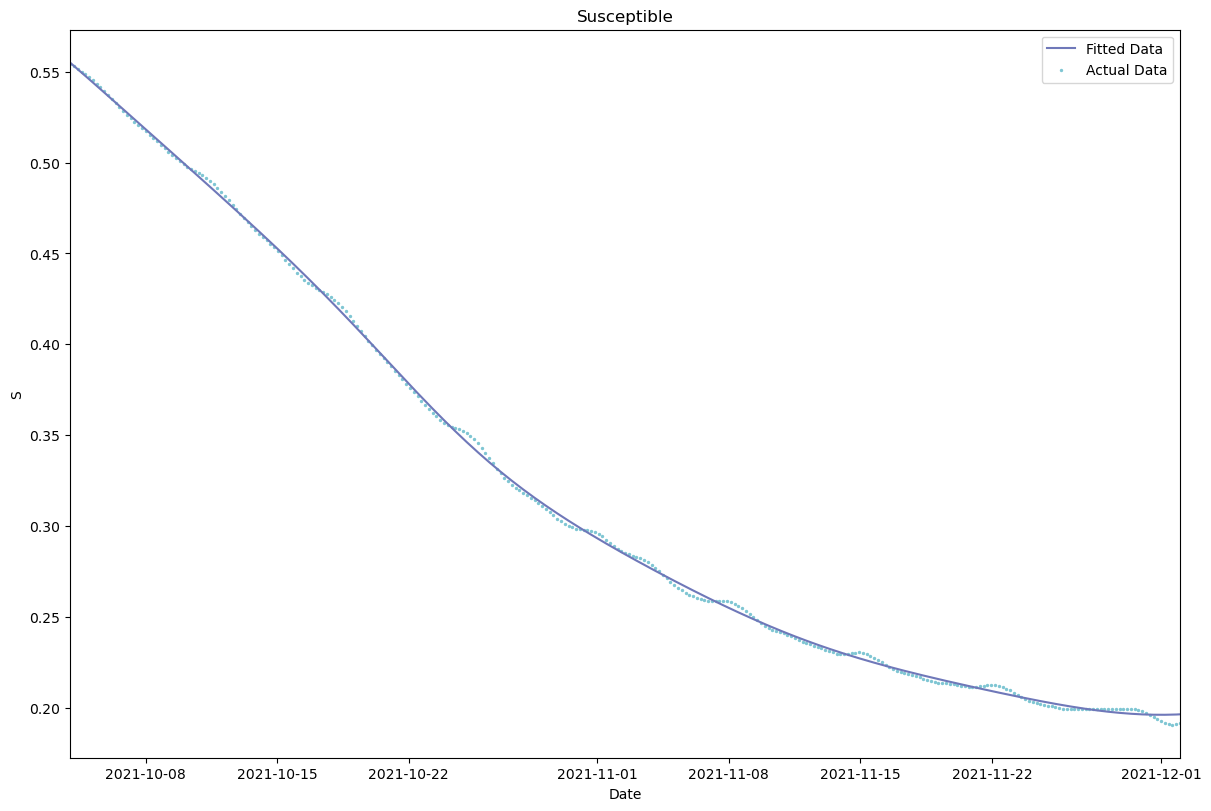

In [11]:
lims = (np.datetime64(st), np.datetime64(ed))

fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,S_pred_m.flatten().tolist(), color=new_purple)
ax1.scatter(dates, SS, s=2, color=new_green, marker='o')  
ax1.set_xlabel('Date')
ax1.set_ylabel('S')
ax1.set_title('Susceptible')
ax1.set_xlim(lims)
ax1.legend(['Fitted Data',r'Actual Data'])



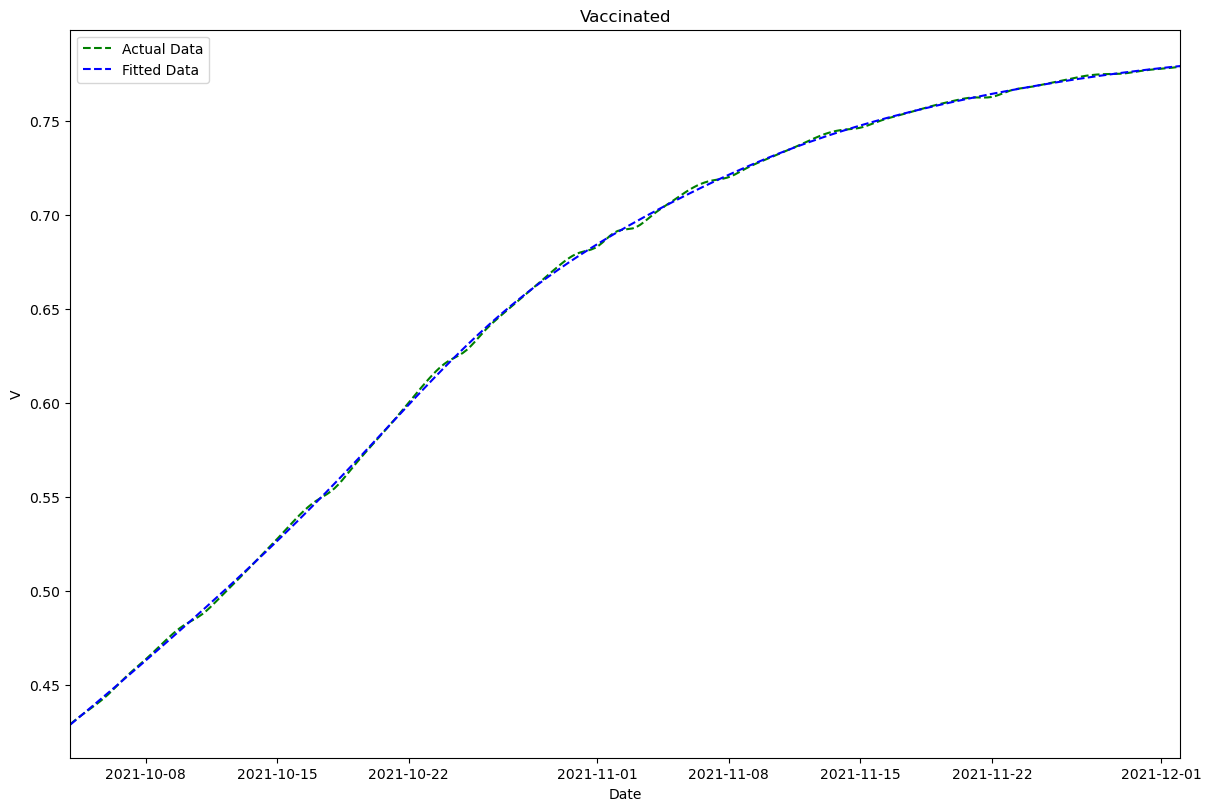

In [12]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,VV, '--g')
ax1.plot(dates,V_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('V')
ax1.set_title('Vaccinated')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

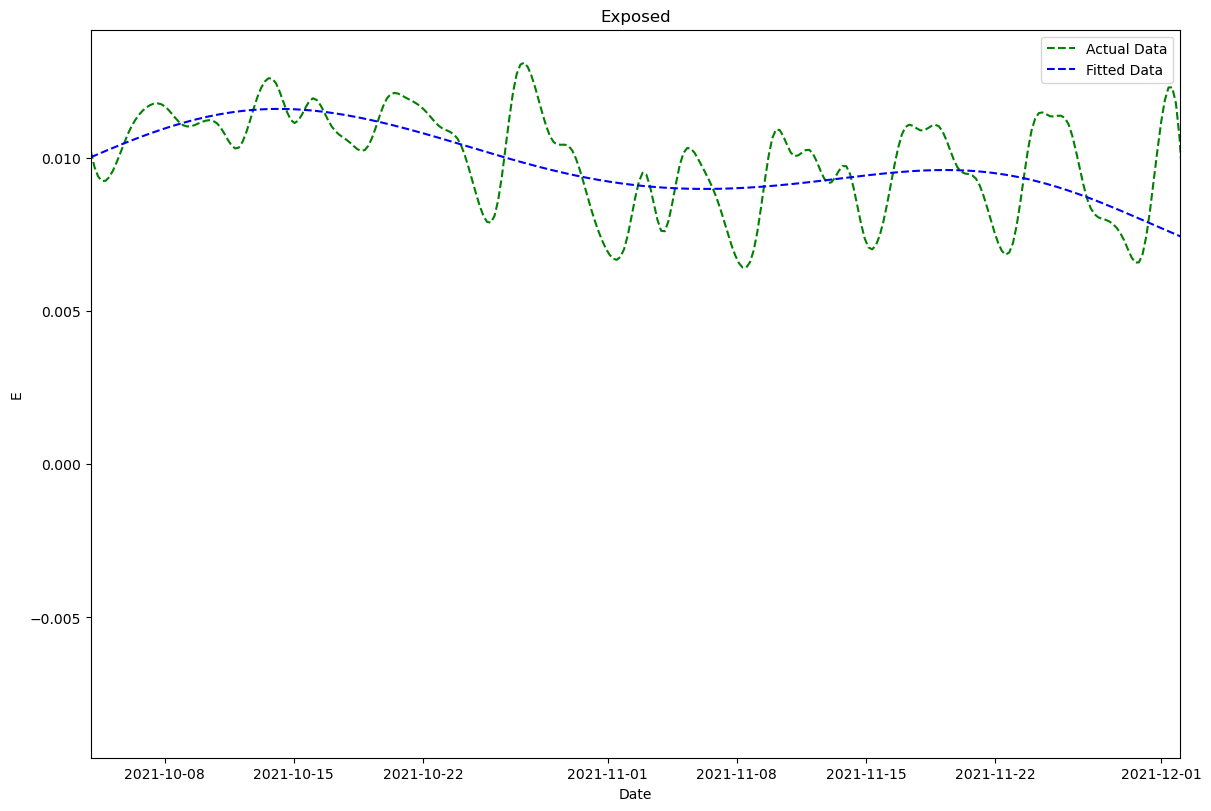

In [13]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,EE, '--g')
ax1.plot(dates,E_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('E')
ax1.set_title('Exposed')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

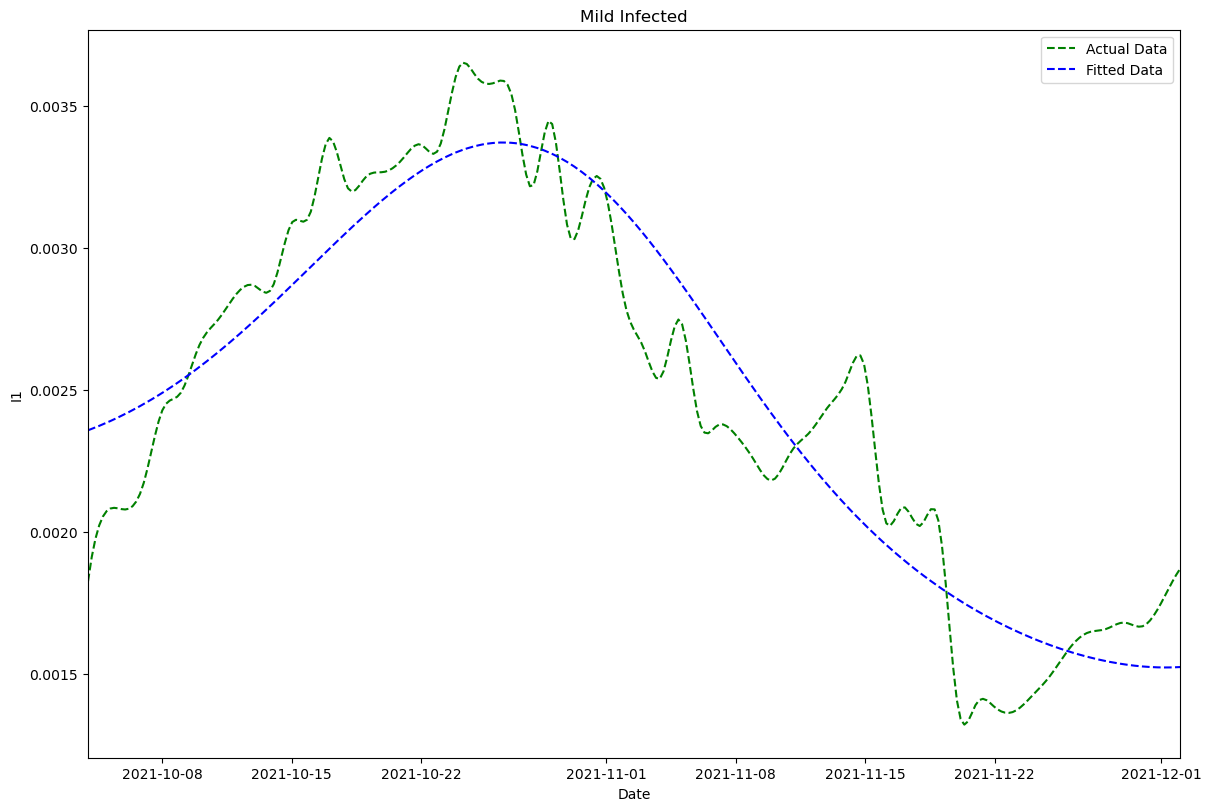

In [14]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I1I, '--g')

ax1.plot(dates,I1_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I1')
ax1.set_title('Mild Infected')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

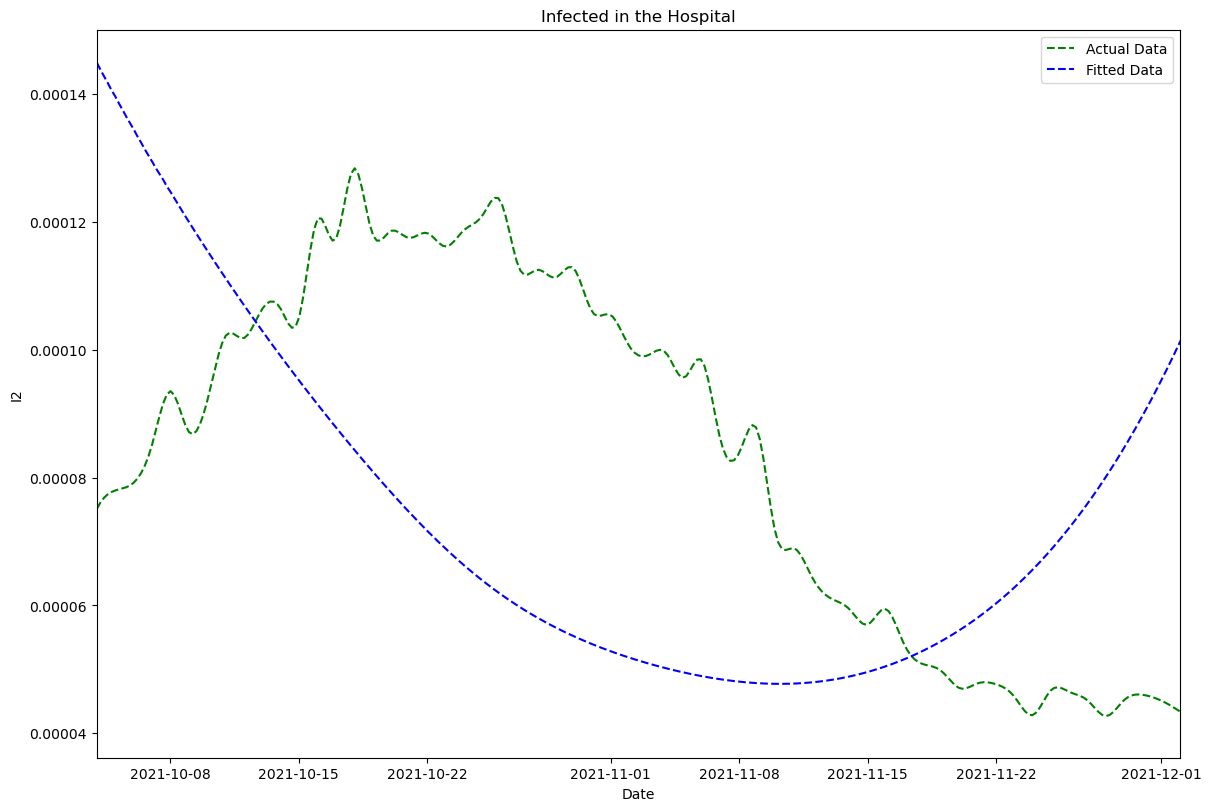

In [15]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I2I, '--g')
ax1.plot(dates,I2_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I2')
ax1.set_title('Infected in the Hospital')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

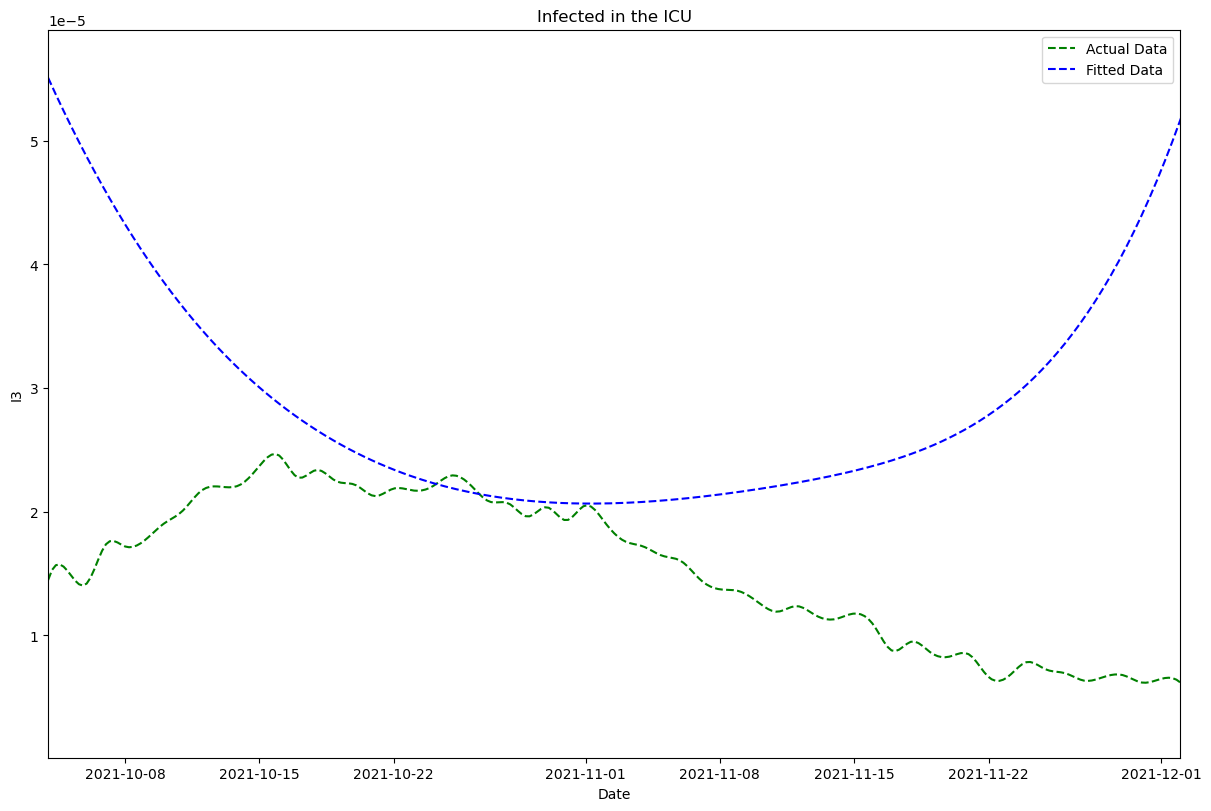

In [16]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,I3I, '--g')
ax1.plot(dates,I3_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('I3')
ax1.set_title('Infected in the ICU')
ax1.set_xlim(lims)

ax1.legend(['Actual Data',r'Fitted Data'])

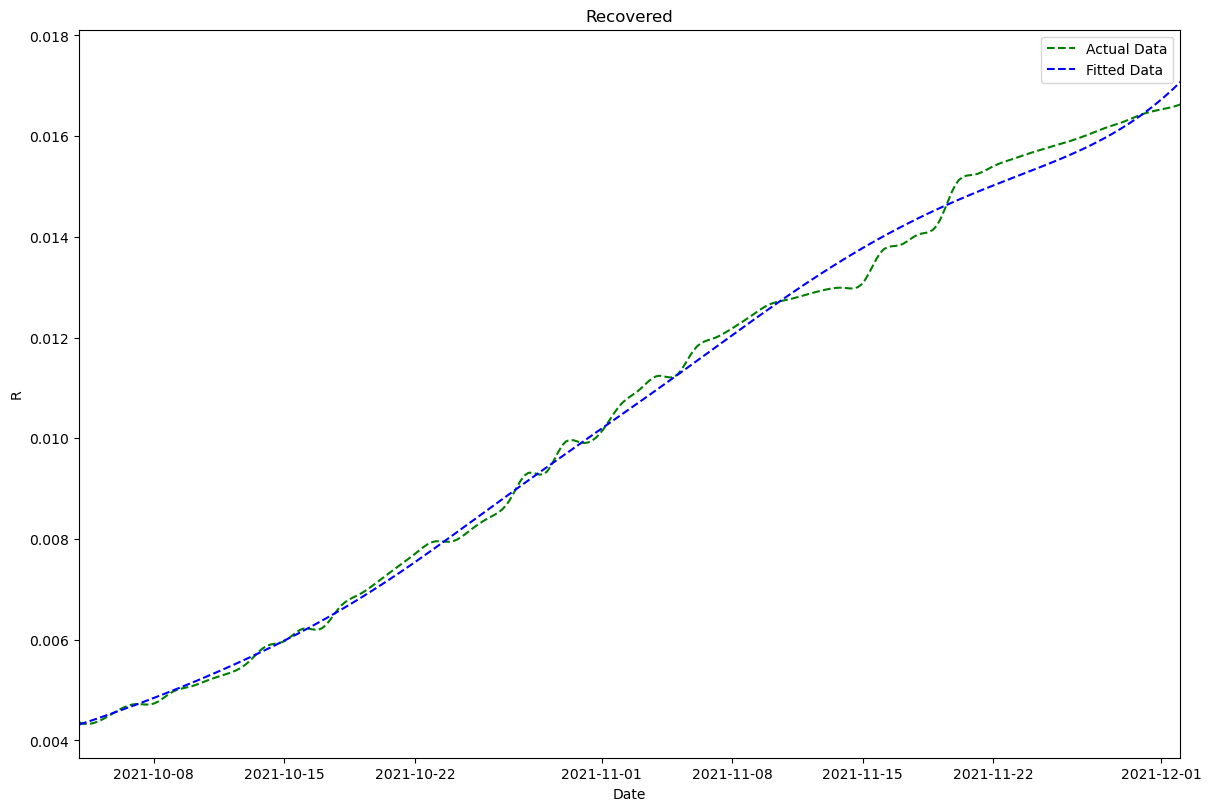

In [17]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,RR, '--g')
ax1.plot(dates,R_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('R')
ax1.set_title('Recovered')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

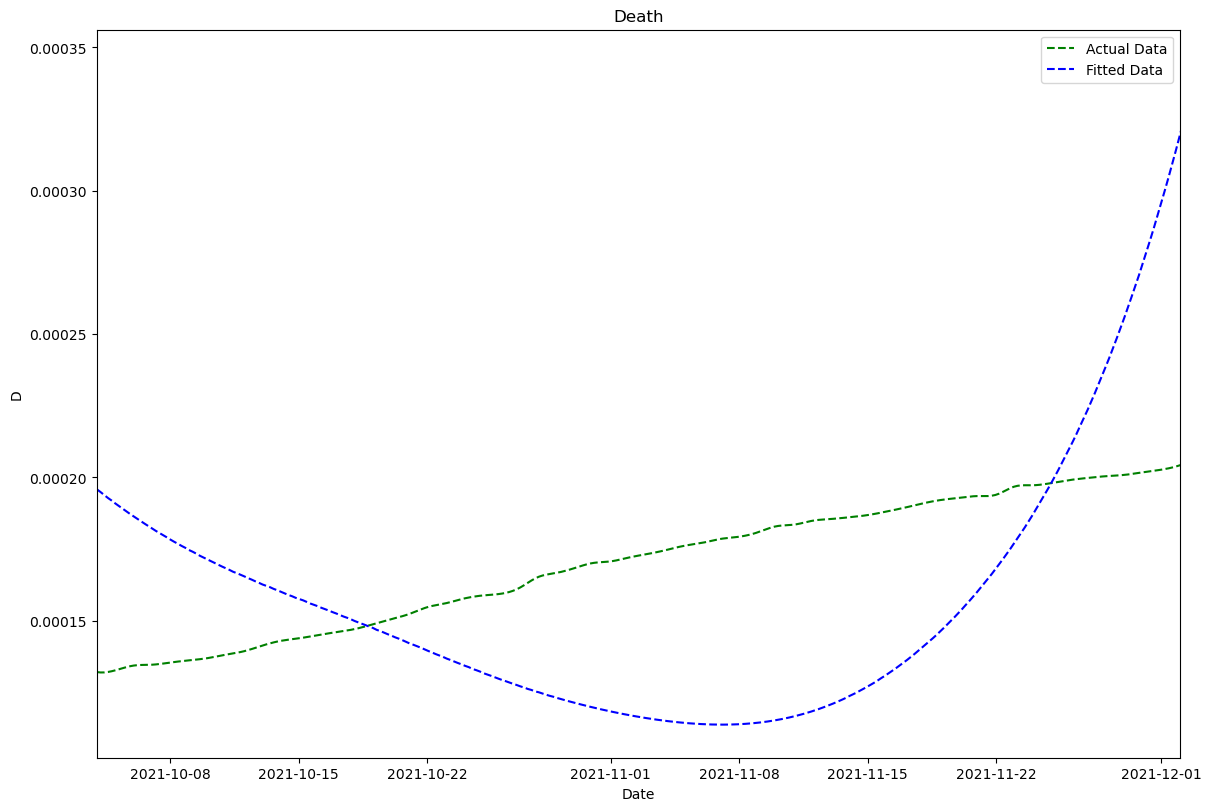

In [18]:
fig1, ax1 = plt.subplots(1, 1,constrained_layout=True,figsize=(12, 8))
ax1.plot(dates,DD, '--g')
ax1.plot(dates,D_pred_m.flatten().tolist(), '--b')

ax1.set_xlabel('Date')
ax1.set_ylabel('D')
ax1.set_title('Death')
ax1.set_xlim(lims)
ax1.legend(['Actual Data',r'Fitted Data'])

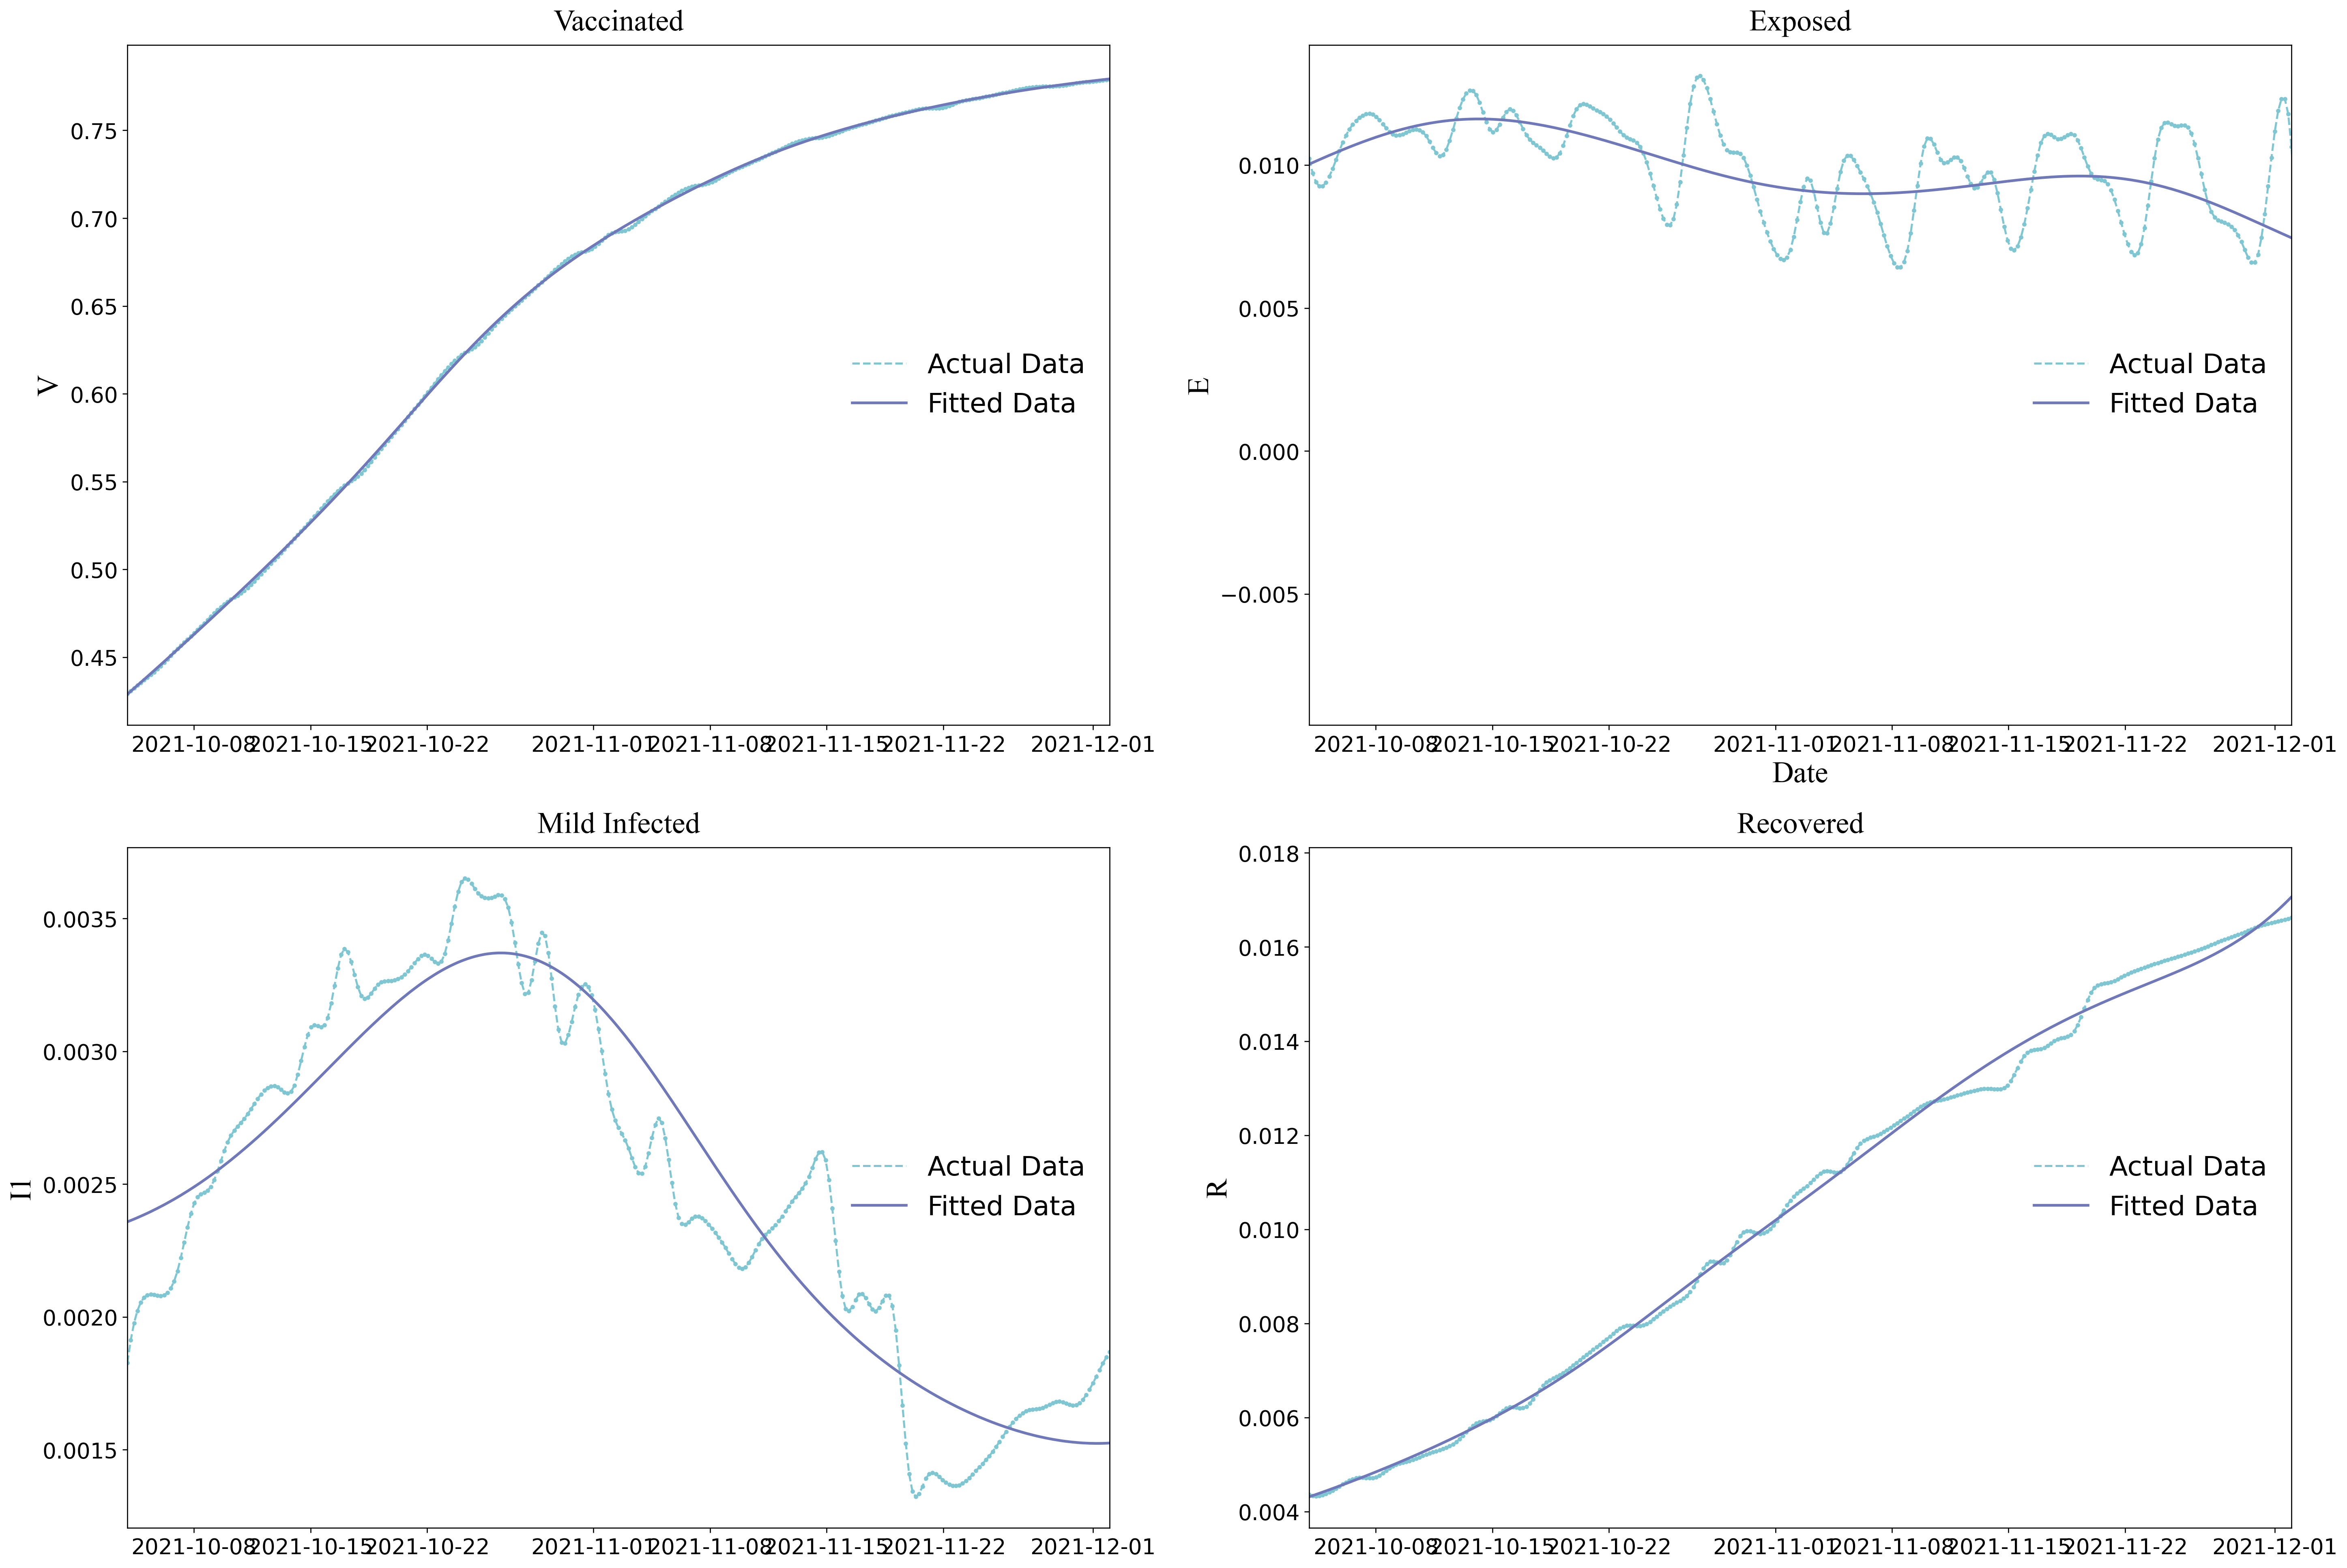

In [19]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, constrained_layout=True, figsize=(24, 16), dpi = 240)

# Custom plots for each subplot
def plot_1(ax):
    ax.plot(dates, VV, lw = 1.5, ls = '--', color = new_green, label = 'Optimal vaccination rate')
    ax.scatter(dates, VV, s=5, color=new_green, marker='o') 
    ax.plot(dates, V_pred_m.flatten().tolist(), lw = 2, color=new_purple)
    #ax.set_xlabel('Date', fontsize=22, family='Times New Roman')
    ax.set_ylabel('V', fontsize=22, family='Times New Roman')
    ax.set_title('Vaccinated', fontsize=22,  y=1.01, family='Times New Roman')
    ax.set_xlim(lims)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(['Actual Data',r'Fitted Data'], loc='right', frameon=False, fontsize=20)



def plot_2(ax):
    ax.plot(dates, EE, lw = 1.5, ls = '--', color = new_green, label = 'Optimal vaccination rate')
    ax.scatter(dates, EE, s=5, color=new_green, marker='o') 
    ax.plot(dates, E_pred_m.flatten().tolist(), lw = 2, color=new_purple) 
    ax.set_xlabel('Date', fontsize=22, family='Times New Roman')
    ax.set_ylabel('E', fontsize=22, family='Times New Roman')
    ax.set_title('Exposed', fontsize=22,  y=1.01, family='Times New Roman')
    ax.set_xlim(lims)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(['Actual Data',r'Fitted Data'], loc='right', frameon=False, fontsize=20)
    

def plot_3(ax):
    ax.plot(dates, I1I, lw = 1.5, ls = '--', color = new_green, label = 'Optimal vaccination rate')
    ax.scatter(dates, I1I, s=5, color=new_green, marker='o') 
    ax.plot(dates, I1_pred_m.flatten().tolist(), lw = 2, color=new_purple)
    #ax.set_xlabel('Date',fontsize=22, family='Times New Roman')
    ax.set_ylabel('I1',fontsize=22, family='Times New Roman')
    ax.set_title('Mild Infected', fontsize=22,  y=1.01, family='Times New Roman')
    ax.set_xlim(lims)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(['Actual Data',r'Fitted Data'], loc='right', frameon=False, fontsize=20)


def plot_4(ax):   
    ax.plot(dates, RR, lw = 1.5, ls = '--', color = new_green, label = 'Optimal vaccination rate')
    ax.scatter(dates, RR, s=5, color=new_green, marker='o') 
    ax.plot(dates, R_pred_m.flatten().tolist(), lw = 2, color=new_purple)
    #ax.set_xlabel('Date',fontsize=22, family='Times New Roman')
    ax.set_ylabel('R',fontsize=22, family='Times New Roman')
    ax.set_title('Recovered', fontsize=22,  y=1.01, family='Times New Roman')
    ax.set_xlim(lims)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.legend(['Actual Data',r'Fitted Data'], loc='right', frameon=False, fontsize=20)



# Apply different plots to each subplot
plot_1(axs[0, 0])
plot_2(axs[0, 1])
plot_3(axs[1, 0])
plot_4(axs[1, 1])


# Display the plot
#plt.show()
plt.rc('font', family='Times New Roman')
plt.savefig('sto_train_data_fitting_'+str(POINTS)+'xpoints_'+str(GRID)+'0%grid_seed'+str(SEED)+'.png')

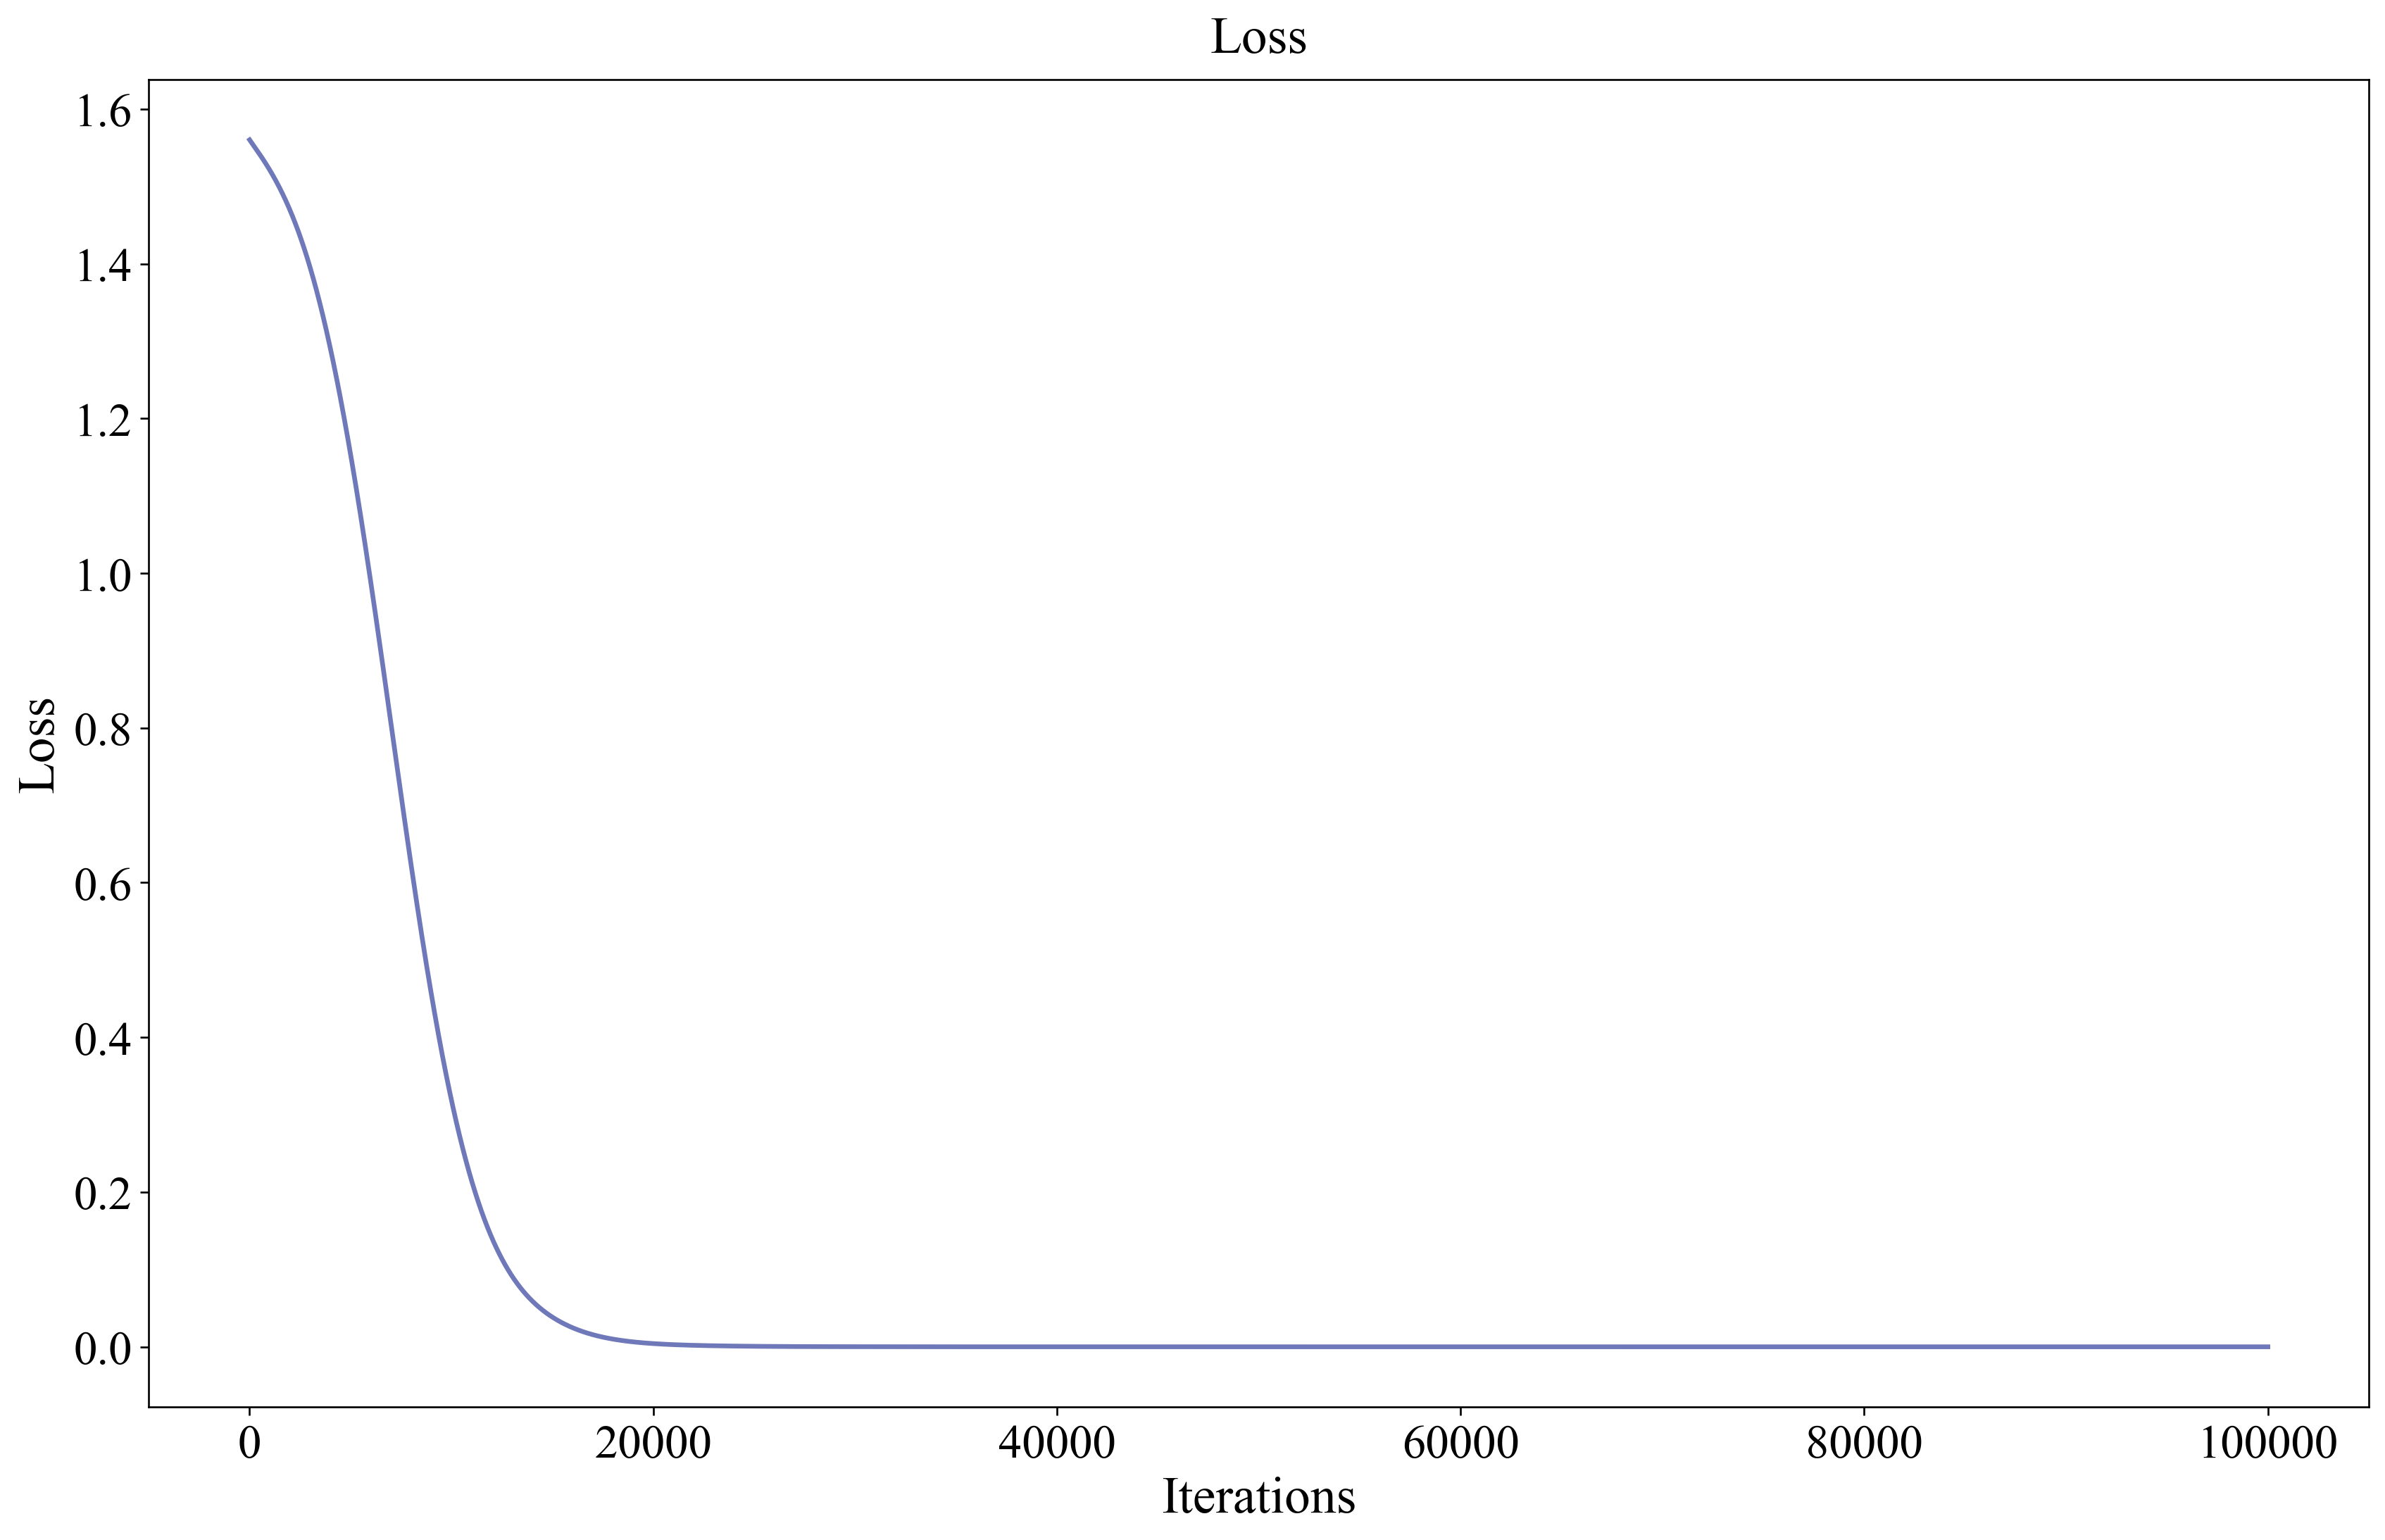

In [20]:
fig2, ax2 = plt.subplots(1, 1,constrained_layout=True,figsize =(14, 9), dpi = 240)
ax2.plot(total_loss, color=new_purple,lw = 2)
ax2.set_xlabel('Iterations',fontsize=22, family='Times New Roman')
ax2.set_ylabel('Loss',fontsize=22, family='Times New Roman')
ax2.set_title('Loss', fontsize=22,  y=1.01, family='Times New Roman')
ax2.tick_params(axis='both', which='major', labelsize=20)
plt.rc('font', family='Times New Roman')
plt.savefig('sto_train_loss_'+str(POINTS)+'xpoints_'+str(GRID)+'0%grid_seed'+str(SEED)+'.png')

In [21]:
print('TOTAL_RMSE', total_rmse)
print('TOTAL_MAPE', total_mape)

TOTAL_RMSE 0.005649298766206149
TOTAL_MAPE 2.1774578326842695


In [22]:
print('alpha_cal =', alpha)
print('sigma_cal =',sigma) 
print('beta1_cal =',beta1) 
print('beta2_cal =',beta2)
print('beta3_cal =',beta3)
print('delta1_cal =',delta1)
print('delta2_cal =',delta2)
print('delta3_cal =',delta3)
print('gamma_cal =',gamma)
print('p1_cal =',p1)
print('p2_cal =',p2)
print('mu_cal =',mu)
print('sigma1_cal =',sigma1) 
print('sigma2_cal =',sigma2)
print('sigma3_cal =',sigma3)
print('sigma4_cal =',sigma4)
print('sigma5_cal =',sigma5)
print('sigma6_cal =',sigma6)
print('sigma7_cal =',sigma7)
print('sigma8_cal =',sigma8)



alpha_cal = 0.00135
sigma_cal = 0.06352
beta1_cal = 0.2812
beta2_cal = 0.15838
beta3_cal = 0.0388
delta1_cal = 0.28505
delta2_cal = 0.28269
delta3_cal = 0.14206
gamma_cal = 0.30954
p1_cal = 0.01845
p2_cal = 0.1431
mu_cal = 0.0042
sigma1_cal = 0.09275
sigma2_cal = 0.03887
sigma3_cal = 0.07517
sigma4_cal = 0.06302
sigma5_cal = 0.07878
sigma6_cal = 0.06123
sigma7_cal = 0.0611
sigma8_cal = 0.06199


# validation

## hyperparameter tuning

PINN SVEI3RD Hyperparameter Tuning
Data loaded successfully!

STARTING HYPERPARAMETER SEARCH
Search method: random
Total configurations to try: 20

Trial 1: {'alpha1': 1.0, 'alpha2': 1.0, 'hidden_layers': [1, 128, 128, 128, 128, 16], 'learning_rate': 1e-06, 'n_mc': 5, 'points_per_day': 5, 'grid': 5}
It: 0, Loss: 1.559e+00, Data: 1.559e+00, Physics: 6.729e-05, Time: 1.75s
It: 1000, Loss: 1.520e+00, Data: 1.520e+00, Physics: 6.331e-05, Time: 9.45s
It: 2000, Loss: 1.468e+00, Data: 1.468e+00, Physics: 5.843e-05, Time: 16.77s
It: 3000, Loss: 1.394e+00, Data: 1.394e+00, Physics: 5.209e-05, Time: 24.76s
It: 4000, Loss: 1.289e+00, Data: 1.289e+00, Physics: 4.419e-05, Time: 32.37s
It: 5000, Loss: 1.153e+00, Data: 1.153e+00, Physics: 3.514e-05, Time: 39.83s
It: 6000, Loss: 9.879e-01, Data: 9.879e-01, Physics: 2.580e-05, Time: 47.29s
It: 7000, Loss: 8.056e-01, Data: 8.056e-01, Physics: 1.727e-05, Time: 54.81s
It: 8000, Loss: 6.225e-01, Data: 6.225e-01, Physics: 1.044e-05, Time: 62.86s
It: 9000, L

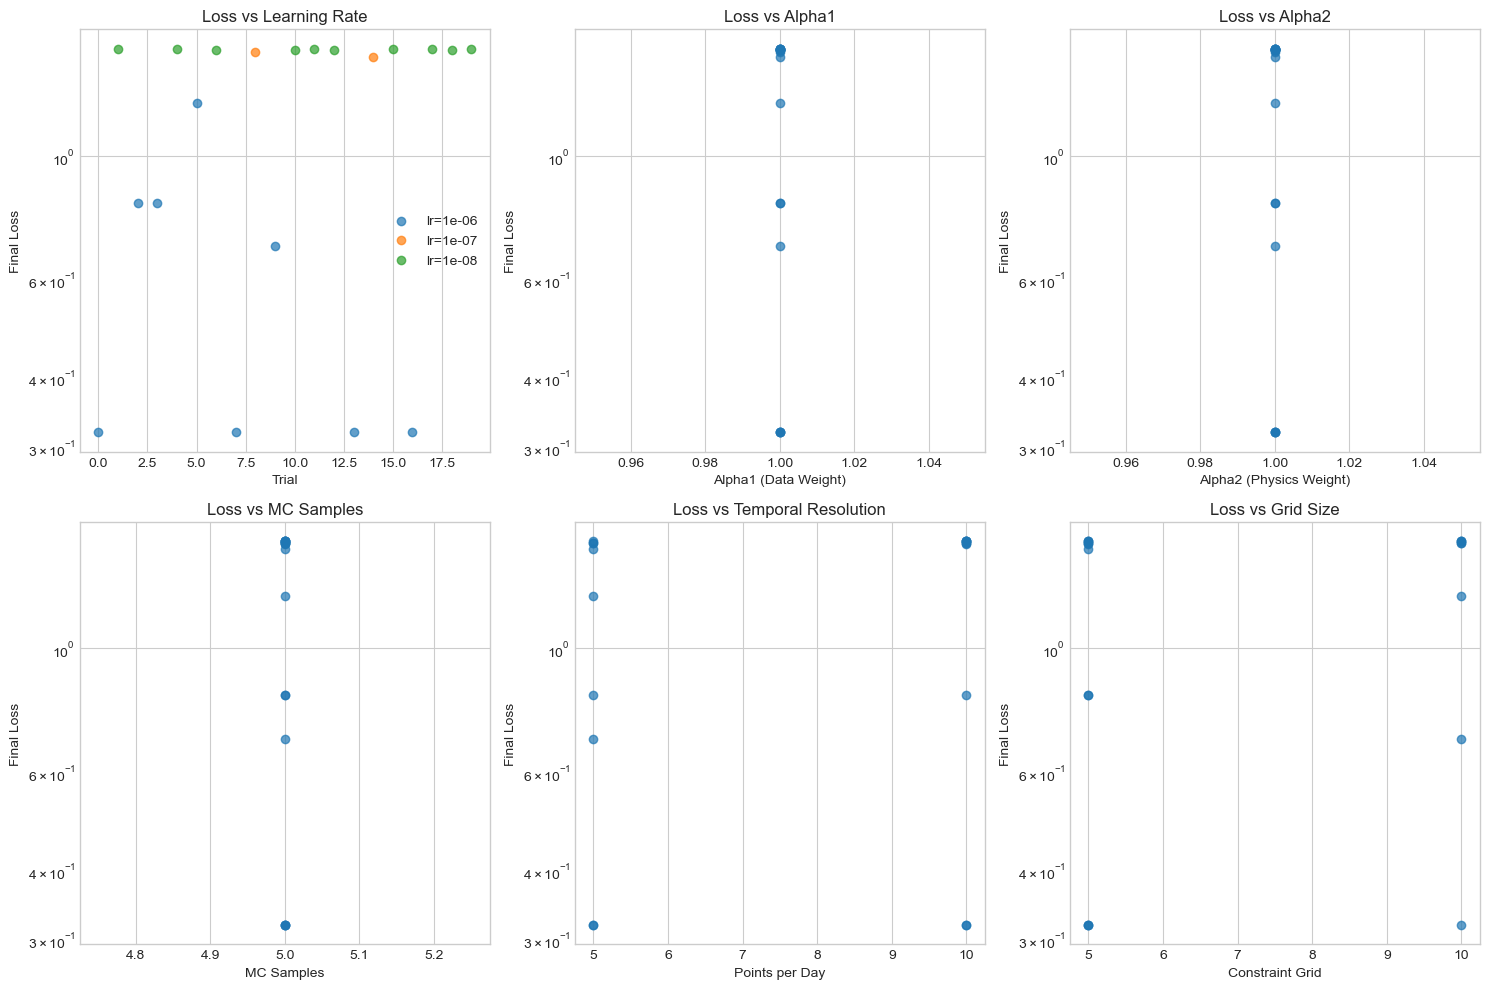


TOP 10 CONFIGURATIONS
    alpha1  alpha2                hidden_layers  learning_rate  n_mc  points_per_day  grid  final_loss  final_data_loss  final_physics_loss  iterations  training_time error
13     1.0     1.0  [1, 128, 128, 128, 128, 16]   1.000000e-06     5              10    10    0.318416         0.318416        2.174229e-07       10000     111.552323  None
7      1.0     1.0  [1, 128, 128, 128, 128, 16]   1.000000e-06     5              10     5    0.318416         0.318416        2.178318e-07       10000     119.247873  None
0      1.0     1.0  [1, 128, 128, 128, 128, 16]   1.000000e-06     5               5     5    0.318648         0.318646        2.852938e-06       10000      79.008514  None
16     1.0     1.0  [1, 128, 128, 128, 128, 16]   1.000000e-06     5               5     5    0.318648         0.318646        2.852938e-06       10000      77.318904  None
9      1.0     1.0    [1, 64, 128, 128, 64, 16]   1.000000e-06     5               5    10    0.688357         0

In [34]:
"""
Hyperparameter Tuning for PINN SVEI3RD Model
=============================================
This script adds hyperparameter tuning capabilities to the stochastic PINN model.
Supports both Grid Search and Random Search strategies.

Usage:
    - Run hyperparameter search first to find optimal parameters
    - Then train final model with best parameters
"""

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import os
import itertools
import json
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
np.set_printoptions(threshold=np.inf)

# =============================================================================
# HYPERPARAMETER CONFIGURATION
# =============================================================================

HYPERPARAMETER_SPACE = {
    # Loss weights
    'alpha1': [1.0],
    'alpha2': [1.0],
    
    # Network architecture options (as tuples for layers)
    'hidden_layers': [
        [1, 64, 64, 64, 16],           # Smaller network
        [1, 128, 128, 128, 16],         # Medium network
        [1, 128, 128, 128, 128, 16],    # Original architecture
        [1, 256, 256, 256, 16],         # Larger network
        [1, 64, 128, 128, 64, 16],      # Pyramid architecture
    ],
    
    # Learning rate
    'learning_rate': [1e-6, 1e-7, 1e-8],
    
    # Monte Carlo samples
    'n_mc': [5],
    
    # Points per day (POINTS)
    'points_per_day': [5, 10],
    
    # Constraint grid size
    'grid': [ 5,10],
}

# Tuning configuration
TUNING_CONFIG = {
    'search_method': 'random',  # 'grid' or 'random'
    'n_random_samples': 20,     # For random search
    'tuning_epochs': 10000,     # Reduced epochs for tuning (faster)
    'final_epochs': 10000,     # Full epochs for final training
    'early_stopping_patience': 2000,  # Stop if no improvement
    'validation_split': 0.2,    # Hold out data for validation
}


# =============================================================================
# MODEL CLASS (Modified for Hyperparameter Tuning)
# =============================================================================

class ClipConstraint(tf.keras.constraints.Constraint):
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.clip_by_value(w, self.min_value, self.max_value)


class PINN_SVEI3RD:
    """
    Physics-Informed Neural Network for SVEI3RD epidemiological model.
    Modified to accept hyperparameters as constructor arguments.
    """
    
    def __init__(self, S, V, E, I1, I2, I3, R, D, T, 
                 layers, alpha1, alpha2, learning_rate,
                 dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8, 
                 n_mc, grid, seed, lb, ub, npoints):
        
        self.t = T
        self.S = S
        self.V = V
        self.E = E
        self.I1 = I1
        self.I2 = I2
        self.I3 = I3
        self.R = R
        self.D = D
        self.dW1 = dW1
        self.dW2 = dW2
        self.dW3 = dW3
        self.dW4 = dW4
        self.dW5 = dW5
        self.dW6 = dW6
        self.dW7 = dW7
        self.dW8 = dW8
        
        # Hyperparameters (now configurable)
        self.learning_rate = learning_rate
        self.n_mc = n_mc
        self.alpha1, self.alpha2 = alpha1, alpha2
        self.layers = layers
        self.grid = grid
        self.seed = seed
        self.lb_time = lb
        self.ub_time = ub
        self.npoints = npoints
        
        self.lb = T.min()
        self.ub = T.max()
        
        tf.set_random_seed(seed)
        np.random.seed(seed)
        
        # Fixed biological parameters
        self.birth = tf.Variable(0.000053, dtype=tf.float32, trainable=False)
        self.dead = tf.Variable(0.000033, dtype=tf.float32, trainable=False)
        
        # Trainable epidemiological parameters with constraints
        self._initialize_epi_parameters()
        
        # Initialize Neural Networks
        self._initialize_networks()
        
        # Build computation graph
        self._build_graph()
        
    def _initialize_epi_parameters(self):
        """Initialize trainable epidemiological parameters with constraints."""
        g = self.grid
        
        self.alpha = tf.Variable(0.0009, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.0009-0.00009*g, 0.0009+0.00009*g))
        self.sigma = tf.Variable(0.0529, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.0529-0.00529*g, 0.0529+0.00529*g))
        self.beta1 = tf.Variable(0.2760, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.2760-0.02760*g, 0.2760+0.02760*g))
        self.beta2 = tf.Variable(0.1532, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.1532-0.01532*g, 0.1532+0.01532*g))
        self.beta3 = tf.Variable(0.0331, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.0331-0.00331*g, 0.0331+0.00331*g))
        self.delta1 = tf.Variable(0.2938, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.2938-0.02938*g, 0.2938+0.02938*g))
        self.delta2 = tf.Variable(0.2916, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.2916-0.02916*g, 0.2916+0.02916*g))
        self.delta3 = tf.Variable(0.1513, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.1513-0.01513*g, 0.1513+0.01513*g))
        self.mu = tf.Variable(0.0028, dtype=tf.float32, trainable=True,
                             constraint=ClipConstraint(0.0028-0.00028*g, 0.0028+0.00028*g))
        self.gamma = tf.Variable(0.3176, dtype=tf.float32, trainable=True,
                                constraint=ClipConstraint(0.3176-0.03176*g, 0.3176+0.03176*g))
        self.p1 = tf.Variable(0.0123, dtype=tf.float32, trainable=True,
                             constraint=ClipConstraint(0.0123-0.00123*g, 0.0123+0.00123*g))
        self.p2 = tf.Variable(0.1519, dtype=tf.float32, trainable=True,
                             constraint=ClipConstraint(0.1519-0.01519*g, 0.1519+0.01519*g))
        
        # Stochastic diffusion parameters
        self.sigma1 = tf.Variable(0.15, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.15-0.015*g, 0.15+0.015*g))
        self.sigma2 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma3 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma4 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma5 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma6 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma7 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        self.sigma8 = tf.Variable(0.07, dtype=tf.float32, trainable=True,
                                 constraint=ClipConstraint(0.07-0.007*g, 0.07+0.007*g))
        
    def _initialize_networks(self):
        """Initialize all neural networks."""
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        
        # Main output network
        self.weights1, self.biases1 = self.initialize_NN(self.layers)
        
        # Additional networks for ensemble (if needed)
        self.weights2, self.biases2 = self.initialize_NN(self.layers)
        self.weights3, self.biases3 = self.initialize_NN(self.layers)
        self.weights4, self.biases4 = self.initialize_NN(self.layers)
        self.weights5, self.biases5 = self.initialize_NN(self.layers)
        self.weights6, self.biases6 = self.initialize_NN(self.layers)
        self.weights7, self.biases7 = self.initialize_NN(self.layers)
        self.weights8, self.biases8 = self.initialize_NN(self.layers)
        self.weights9, self.biases9 = self.initialize_NN(self.layers)
        self.weights10, self.biases10 = self.initialize_NN(self.layers)
        self.weights11, self.biases11 = self.initialize_NN(self.layers)
        self.weights12, self.biases12 = self.initialize_NN(self.layers)
        self.weights13, self.biases13 = self.initialize_NN(self.layers)
        self.weights14, self.biases14 = self.initialize_NN(self.layers)
        self.weights15, self.biases15 = self.initialize_NN(self.layers)
        self.weights16, self.biases16 = self.initialize_NN(self.layers)
        
    def _build_graph(self):
        """Build the TensorFlow computation graph."""
        self.sess = tf.Session(config=tf.ConfigProto(
            allow_soft_placement=True,
            log_device_placement=False  # Set to False to reduce log spam during tuning
        ))
        
        # Placeholders
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.S_tf = tf.placeholder(tf.float32, shape=[None, self.S.shape[1]])
        self.V_tf = tf.placeholder(tf.float32, shape=[None, self.V.shape[1]])
        self.E_tf = tf.placeholder(tf.float32, shape=[None, self.E.shape[1]])
        self.I1_tf = tf.placeholder(tf.float32, shape=[None, self.I1.shape[1]])
        self.I2_tf = tf.placeholder(tf.float32, shape=[None, self.I2.shape[1]])
        self.I3_tf = tf.placeholder(tf.float32, shape=[None, self.I3.shape[1]])
        self.R_tf = tf.placeholder(tf.float32, shape=[None, self.R.shape[1]])
        self.D_tf = tf.placeholder(tf.float32, shape=[None, self.D.shape[1]])
        self.dW1_tf = tf.placeholder(tf.float32, shape=[None, self.dW1.shape[1]])
        self.dW2_tf = tf.placeholder(tf.float32, shape=[None, self.dW2.shape[1]])
        self.dW3_tf = tf.placeholder(tf.float32, shape=[None, self.dW3.shape[1]])
        self.dW4_tf = tf.placeholder(tf.float32, shape=[None, self.dW4.shape[1]])
        self.dW5_tf = tf.placeholder(tf.float32, shape=[None, self.dW5.shape[1]])
        self.dW6_tf = tf.placeholder(tf.float32, shape=[None, self.dW6.shape[1]])
        self.dW7_tf = tf.placeholder(tf.float32, shape=[None, self.dW7.shape[1]])
        self.dW8_tf = tf.placeholder(tf.float32, shape=[None, self.dW8.shape[1]])
        
        # Loss tracking
        self.total_loss = []
        self.loss_data = []
        self.loss_res = []
        
        # Network outputs
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        
        self.S_pred, self.V_pred, self.E_pred, self.I1_pred, self.I2_pred, \
        self.I3_pred, self.R_pred, self.D_pred, _, _, _, _, _, _, _, _ = self.net_sir(self.t_tf)
        
        self.l_em, self.s_list, self.v_list, self.e_list, self.i1_list, \
        self.i2_list, self.i3_list, self.r_list, self.d_list = self.euler_maruyama_loss(self.t_tf, self.n_mc)
        
        # Physics loss (Euler-Maruyama)
        self.lossRes = tf.reduce_mean(tf.square(self.l_em))
        
        # Data loss
        self.S_loss = tf.reduce_mean(tf.square(self.S_tf - self.S_pred))
        self.V_loss = tf.reduce_mean(tf.square(self.V_tf - self.V_pred))
        self.E_loss = tf.reduce_mean(tf.square(self.E_tf - self.E_pred))
        self.I1_loss = tf.reduce_mean(tf.square(self.I1_tf - self.I1_pred))
        self.I2_loss = tf.reduce_mean(tf.square(self.I2_tf - self.I2_pred))
        self.I3_loss = tf.reduce_mean(tf.square(self.I3_tf - self.I3_pred))
        self.R_loss = tf.reduce_mean(tf.square(self.R_tf - self.R_pred))
        self.D_loss = tf.reduce_mean(tf.square(self.D_tf - self.D_pred))
        
        self.lossData = (self.S_loss + self.V_loss + self.E_loss + 
                        self.I1_loss + self.I2_loss + self.I3_loss + 
                        self.R_loss + self.D_loss)
        
        # Total PINN loss
        self.loss = self.alpha1 * self.lossData + self.alpha2 * self.lossRes
        
        # Optimizer
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        self.optimizer_Adam = tf.compat.v1.train.AdamOptimizer(self.learning_rate)
        self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)
        
        # Initialize variables
        init = tf.global_variables_initializer()
        self.sess.run(init)
        
    def initialize_NN(self, layers):
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        weights = []
        biases = []
        num_layers = len(layers)
        
        for l in range(0, num_layers-1):
            tf.set_random_seed(self.seed)
            np.random.seed(self.seed)
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1, layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases
    
    def xavier_init(self, size):
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
        return tf.Variable(
            tf.random.truncated_normal([in_dim, out_dim], stddev=xavier_stddev, seed=self.seed),
            dtype=tf.float32
        )
    
    def neural_net(self, X, weights, biases):
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        num_layers = len(weights) + 1
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        for l in range(0, num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.nn.sigmoid(tf.add(tf.matmul(H, W), b))
        return Y
    
    def net_sir(self, t):
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        SVEI3RD = self.neural_net(t, self.weights1, self.biases1)
        S = SVEI3RD[:, 0:1]
        V = SVEI3RD[:, 1:2]
        E = SVEI3RD[:, 2:3]
        I1 = SVEI3RD[:, 3:4]
        I2 = SVEI3RD[:, 4:5]
        I3 = SVEI3RD[:, 5:6]
        R = SVEI3RD[:, 6:7]
        D = SVEI3RD[:, 7:8]
        Dw1 = SVEI3RD[:, 8:9]
        Dw2 = SVEI3RD[:, 9:10]
        Dw3 = SVEI3RD[:, 10:11]
        Dw4 = SVEI3RD[:, 11:12]
        Dw5 = SVEI3RD[:, 12:13]
        Dw6 = SVEI3RD[:, 13:14]
        Dw7 = SVEI3RD[:, 14:15]
        Dw8 = SVEI3RD[:, 15:16]
        return S, V, E, I1, I2, I3, R, D, Dw1, Dw2, Dw3, Dw4, Dw5, Dw6, Dw7, Dw8
    
    def SIR_equations(self, S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma, 
                      beta1, beta2, beta3, delta1, delta2, delta3, mu, gamma, p1, p2,
                      dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8,
                      sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt):
        
        dS = (birth - (beta1*I1 + beta2*I2 + beta3*I3)*S - alpha*S - dead*S) * dt + (sigma1*S) * math.sqrt(dt) * dW1
        dV = (alpha*S - sigma*(beta1*I1 + beta2*I2 + beta3*I3)*V - dead*V) * dt + (sigma2*V) * math.sqrt(dt) * dW2
        dE = ((beta1*I1 + beta2*I2 + beta3*I3)*S + sigma*(beta1*I1 + beta2*I2 + beta3*I3)*V - gamma*E - dead*E) * dt + (sigma3*E) * math.sqrt(dt) * dW3
        dI1 = (gamma*E - (delta1 + p1)*I1 - dead*I1) * dt + (sigma4*I1) * math.sqrt(dt) * dW4
        dI2 = (p1*I1 - (delta2 + p2)*I2 - dead*I2) * dt + (sigma5*I2) * math.sqrt(dt) * dW5
        dI3 = (p2*I2 - (delta3 + mu)*I3 - dead*I3) * dt + (sigma6*I3) * math.sqrt(dt) * dW6
        dR = (delta1*I1 + delta2*I2 + delta3*I3 - dead*R) * dt + (sigma7*R) * math.sqrt(dt) * dW7
        dD = (mu*I3) * dt + (sigma8*D) * math.sqrt(dt) * dW8
        return dS, dV, dE, dI1, dI2, dI3, dR, dD
    
    def euler_maruyama_loss(self, t, n_mc):
        birth = self.birth
        dead = self.dead
        alpha = self.alpha
        sigma = self.sigma
        beta1 = self.beta1
        beta2 = self.beta2
        beta3 = self.beta3
        delta1 = self.delta1
        delta2 = self.delta2
        delta3 = self.delta3
        mu = self.mu
        gamma = self.gamma
        p1 = self.p1
        p2 = self.p2
        sigma1 = self.sigma1
        sigma2 = self.sigma2
        sigma3 = self.sigma3
        sigma4 = self.sigma4
        sigma5 = self.sigma5
        sigma6 = self.sigma6
        sigma7 = self.sigma7
        sigma8 = self.sigma8
        
        dt = self.ub_time / self.npoints
        
        S_list, V_list, E_list = [], [], []
        I1_list, I2_list, I3_list = [], [], []
        R_list, D_list = [], []
        loss = []
        
        for _ in range(n_mc):
            tf.set_random_seed(self.seed)
            np.random.seed(self.seed)
            
            S, V, E, I1, I2, I3, R, D, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8 = self.net_sir(t)
            
            S_list.append(S)
            V_list.append(V)
            E_list.append(E)
            I1_list.append(I1)
            I2_list.append(I2)
            I3_list.append(I3)
            R_list.append(R)
            D_list.append(D)
            
            dS, dV, dE, dI1, dI2, dI3, dR, dD = self.SIR_equations(
                S, V, E, I1, I2, I3, R, D, birth, dead, alpha, sigma,
                beta1, beta2, beta3, delta1, delta2, delta3, mu, gamma,
                p1, p2, dW1, dW2, dW3, dW4, dW5, dW6, dW7, dW8,
                sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7, sigma8, dt
            )
            
            # Physics-informed data points
            S_phy = S + dS
            V_phy = V + dV
            E_phy = E + dE
            I1_phy = I1 + dI1
            I2_phy = I2 + dI2
            I3_phy = I3 + dI3
            R_phy = R + dR
            D_phy = D + dD
            
            # Residuals
            e1 = S_phy[:-1] - S[1:]
            e2 = V_phy[:-1] - V[1:]
            e3 = E_phy[:-1] - E[1:]
            e4 = I1_phy[:-1] - I1[1:]
            e5 = I2_phy[:-1] - I2[1:]
            e6 = I3_phy[:-1] - I3[1:]
            e7 = R_phy[:-1] - R[1:]
            e8 = D_phy[:-1] - D[1:]
            
            l = (tf.reduce_mean(tf.square(e1)) + tf.reduce_mean(tf.square(e2)) +
                 tf.reduce_mean(tf.square(e3)) + tf.reduce_mean(tf.square(e4)) +
                 tf.reduce_mean(tf.square(e5)) + tf.reduce_mean(tf.square(e6)) +
                 tf.reduce_mean(tf.square(e7)) + tf.reduce_mean(tf.square(e8)))
            
            loss.append(l)
        
        l_em = tf.stack(tf.reduce_mean(loss), axis=0)
        return l_em, S_list, V_list, E_list, I1_list, I2_list, I3_list, R_list, D_list
    
    def train(self, nIter, early_stopping_patience=None, verbose=True, print_every=500):
        """
        Train the model with optional early stopping.
        
        Args:
            nIter: Number of iterations
            early_stopping_patience: Stop if no improvement for this many iterations
            verbose: Whether to print progress
            print_every: Print frequency
            
        Returns:
            Dictionary with training history and final metrics
        """
        tf.set_random_seed(self.seed)
        
        tf_dict = {
            self.t_tf: self.t,
            self.S_tf: self.S,
            self.V_tf: self.V,
            self.E_tf: self.E,
            self.I1_tf: self.I1,
            self.I2_tf: self.I2,
            self.I3_tf: self.I3,
            self.R_tf: self.R,
            self.D_tf: self.D,
            self.dW1_tf: self.dW1,
            self.dW2_tf: self.dW2,
            self.dW3_tf: self.dW3,
            self.dW4_tf: self.dW4,
            self.dW5_tf: self.dW5,
            self.dW6_tf: self.dW6,
            self.dW7_tf: self.dW7,
            self.dW8_tf: self.dW8
        }
        
        start_time = time.time()
        loss_seq = []
        best_loss = float('inf')
        patience_counter = 0
        
        for it in range(nIter):
            tf.set_random_seed(self.seed)
            np.random.seed(self.seed)
            
            self.sess.run(self.train_op_Adam, tf_dict)
            loss_t = self.sess.run(self.loss, tf_dict)
            loss_d = self.sess.run(self.lossData, tf_dict)
            loss_p = self.sess.run(self.lossRes, tf_dict)
            
            self.total_loss.append(loss_t)
            self.loss_data.append(loss_d)
            self.loss_res.append(loss_p)
            loss_seq.append(loss_t)
            
            # Early stopping check
            if early_stopping_patience is not None:
                if loss_t < best_loss:
                    best_loss = loss_t
                    patience_counter = 0
                else:
                    patience_counter += 1
                    
                if patience_counter >= early_stopping_patience:
                    if verbose:
                        print(f'Early stopping at iteration {it}')
                    break
            
            # Print progress
            if verbose and it % print_every == 0:
                elapsed = time.time() - start_time
                print(f'It: {it}, Loss: {loss_t:.3e}, Data: {loss_d:.3e}, Physics: {loss_p:.3e}, Time: {elapsed:.2f}s')
        
        final_loss = self.sess.run(self.loss, tf_dict)
        final_data_loss = self.sess.run(self.lossData, tf_dict)
        final_physics_loss = self.sess.run(self.lossRes, tf_dict)
        
        return {
            'loss_history': loss_seq,
            'final_loss': final_loss,
            'final_data_loss': final_data_loss,
            'final_physics_loss': final_physics_loss,
            'iterations': len(loss_seq),
            'training_time': time.time() - start_time
        }
    
    def predict(self, t_star):
        tf.set_random_seed(self.seed)
        np.random.seed(self.seed)
        tf_dict = {self.t_tf: t_star}
        
        S_l = self.sess.run(self.s_list, tf_dict)
        V_l = self.sess.run(self.v_list, tf_dict)
        E_l = self.sess.run(self.e_list, tf_dict)
        I1_l = self.sess.run(self.i1_list, tf_dict)
        I2_l = self.sess.run(self.i2_list, tf_dict)
        I3_l = self.sess.run(self.i3_list, tf_dict)
        R_l = self.sess.run(self.r_list, tf_dict)
        D_l = self.sess.run(self.d_list, tf_dict)
        
        return S_l, V_l, E_l, I1_l, I2_l, I3_l, R_l, D_l
    
    def get_learned_parameters(self):
        """Return learned epidemiological parameters."""
        return {
            'alpha': self.sess.run(self.alpha),
            'sigma': self.sess.run(self.sigma),
            'beta1': self.sess.run(self.beta1),
            'beta2': self.sess.run(self.beta2),
            'beta3': self.sess.run(self.beta3),
            'delta1': self.sess.run(self.delta1),
            'delta2': self.sess.run(self.delta2),
            'delta3': self.sess.run(self.delta3),
            'mu': self.sess.run(self.mu),
            'gamma': self.sess.run(self.gamma),
            'p1': self.sess.run(self.p1),
            'p2': self.sess.run(self.p2),
            'sigma1': self.sess.run(self.sigma1),
            'sigma2': self.sess.run(self.sigma2),
            'sigma3': self.sess.run(self.sigma3),
            'sigma4': self.sess.run(self.sigma4),
            'sigma5': self.sess.run(self.sigma5),
            'sigma6': self.sess.run(self.sigma6),
            'sigma7': self.sess.run(self.sigma7),
            'sigma8': self.sess.run(self.sigma8),
        }
    
    def close(self):
        """Close the TensorFlow session."""
        self.sess.close()


# =============================================================================
# HYPERPARAMETER TUNING CLASS
# =============================================================================

class HyperparameterTuner:
    """
    Hyperparameter tuning for PINN SVEI3RD model.
    Supports grid search and random search strategies.
    """
    
    def __init__(self, data, hyperparameter_space, tuning_config, 
                 lb=0, ub=60, N0=6629870, seed=123):
        self.data = data
        self.hyperparameter_space = hyperparameter_space
        self.tuning_config = tuning_config
        self.lb = lb
        self.ub = ub
        self.N0 = N0
        self.seed = seed
        
        self.results = []
        self.best_params = None
        self.best_loss = float('inf')
        
    def _generate_parameter_combinations(self):
        """Generate hyperparameter combinations based on search method."""
        if self.tuning_config['search_method'] == 'grid':
            # Full grid search
            keys = list(self.hyperparameter_space.keys())
            values = list(self.hyperparameter_space.values())
            combinations = list(itertools.product(*values))
            return [dict(zip(keys, combo)) for combo in combinations]
        
        elif self.tuning_config['search_method'] == 'random':
            # Random search
            n_samples = self.tuning_config['n_random_samples']
            combinations = []
            
            np.random.seed(self.seed)
            for _ in range(n_samples):
                combo = {}
                for key, values in self.hyperparameter_space.items():
                    combo[key] = np.random.choice(values) if isinstance(values[0], (int, float, str)) else values[np.random.randint(len(values))]
                combinations.append(combo)
            
            return combinations
        
        else:
            raise ValueError(f"Unknown search method: {self.tuning_config['search_method']}")
    
    def _prepare_data(self, points_per_day):
        """Prepare training data with given points per day."""
        npoints = self.ub * points_per_day
        
        tdat = self.data.reindex(index=self.data.index[::1])
        s_real = tdat["S"]
        v_real = tdat["V"]
        e_real = tdat["E"]
        i1_real = tdat["I1"]
        i2_real = tdat["I2"]
        i3_real = tdat["I3"]
        r_real = tdat["R"]
        d_real = tdat["D"]
        
        S = np.array(s_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        V = np.array(v_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        E = np.array(e_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        I1 = np.array(i1_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        I2 = np.array(i2_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        I3 = np.array(i3_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        R = np.array(r_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        D = np.array(d_real.values).reshape((-1, 1))[self.lb:self.ub, :]
        
        # Normalize
        S = S / self.N0
        V = V / self.N0
        E = E / self.N0
        I1 = I1 / self.N0
        I2 = I2 / self.N0
        I3 = I3 / self.N0
        R = R / self.N0
        D = D / self.N0
        
        # Interpolate
        T_dat = np.linspace(self.lb, self.ub, len(S))
        T_train = np.linspace(self.lb, self.ub, npoints)
        
        from scipy.interpolate import CubicSpline
        
        cs_S = CubicSpline(T_dat, S.flatten())
        cs_V = CubicSpline(T_dat, V.flatten())
        cs_E = CubicSpline(T_dat, E.flatten())
        cs_I1 = CubicSpline(T_dat, I1.flatten())
        cs_I2 = CubicSpline(T_dat, I2.flatten())
        cs_I3 = CubicSpline(T_dat, I3.flatten())
        cs_R = CubicSpline(T_dat, R.flatten())
        cs_D = CubicSpline(T_dat, D.flatten())
        
        S_interp = cs_S(T_train).reshape(-1, 1)
        V_interp = cs_V(T_train).reshape(-1, 1)
        E_interp = cs_E(T_train).reshape(-1, 1)
        I1_interp = cs_I1(T_train).reshape(-1, 1)
        I2_interp = cs_I2(T_train).reshape(-1, 1)
        I3_interp = cs_I3(T_train).reshape(-1, 1)
        R_interp = cs_R(T_train).reshape(-1, 1)
        D_interp = cs_D(T_train).reshape(-1, 1)
        T_train = T_train.reshape(-1, 1)
        
        # Generate Brownian increments
        np.random.seed(self.seed)
        dW1 = np.random.randn(npoints, 1)
        dW2 = np.random.randn(npoints, 1)
        dW3 = np.random.randn(npoints, 1)
        dW4 = np.random.randn(npoints, 1)
        dW5 = np.random.randn(npoints, 1)
        dW6 = np.random.randn(npoints, 1)
        dW7 = np.random.randn(npoints, 1)
        dW8 = np.random.randn(npoints, 1)
        
        return {
            'S': S_interp, 'V': V_interp, 'E': E_interp,
            'I1': I1_interp, 'I2': I2_interp, 'I3': I3_interp,
            'R': R_interp, 'D': D_interp, 'T': T_train,
            'dW1': dW1, 'dW2': dW2, 'dW3': dW3, 'dW4': dW4,
            'dW5': dW5, 'dW6': dW6, 'dW7': dW7, 'dW8': dW8,
            'npoints': npoints
        }
    
    def _train_single_config(self, params, trial_num):
        """Train model with a single hyperparameter configuration."""
        print(f"\n{'='*60}")
        print(f"Trial {trial_num}: {params}")
        print('='*60)
        
        # Clear TensorFlow graph
        tf.reset_default_graph()
        
        # Prepare data
        data_dict = self._prepare_data(params['points_per_day'])
        
        # Build model
        model = PINN_SVEI3RD(
            S=data_dict['S'], V=data_dict['V'], E=data_dict['E'],
            I1=data_dict['I1'], I2=data_dict['I2'], I3=data_dict['I3'],
            R=data_dict['R'], D=data_dict['D'], T=data_dict['T'],
            layers=params['hidden_layers'],
            alpha1=params['alpha1'],
            alpha2=params['alpha2'],
            learning_rate=params['learning_rate'],
            dW1=data_dict['dW1'], dW2=data_dict['dW2'],
            dW3=data_dict['dW3'], dW4=data_dict['dW4'],
            dW5=data_dict['dW5'], dW6=data_dict['dW6'],
            dW7=data_dict['dW7'], dW8=data_dict['dW8'],
            n_mc=params['n_mc'],
            grid=params['grid'],
            seed=self.seed,
            lb=self.lb,
            ub=self.ub,
            npoints=data_dict['npoints']
        )
        
        # Train with reduced epochs and early stopping
        result = model.train(
            nIter=self.tuning_config['tuning_epochs'],
            early_stopping_patience=self.tuning_config['early_stopping_patience'],
            verbose=True,
            print_every=1000
        )
        
        # Get learned parameters
        learned_params = model.get_learned_parameters()
        
        # Close session
        model.close()
        
        return {
            'params': params,
            'final_loss': result['final_loss'],
            'final_data_loss': result['final_data_loss'],
            'final_physics_loss': result['final_physics_loss'],
            'iterations': result['iterations'],
            'training_time': result['training_time'],
            'learned_epi_params': learned_params
        }
    
    def run_search(self):
        """Run the hyperparameter search."""
        print("\n" + "="*60)
        print("STARTING HYPERPARAMETER SEARCH")
        print("="*60)
        print(f"Search method: {self.tuning_config['search_method']}")
        
        combinations = self._generate_parameter_combinations()
        print(f"Total configurations to try: {len(combinations)}")
        
        start_time = time.time()
        
        for i, params in enumerate(combinations):
            try:
                result = self._train_single_config(params, i + 1)
                self.results.append(result)
                
                # Track best
                if result['final_loss'] < self.best_loss:
                    self.best_loss = result['final_loss']
                    self.best_params = params.copy()
                    print(f"\n*** NEW BEST: Loss = {self.best_loss:.6e} ***")
                    
            except Exception as e:
                print(f"Error in trial {i+1}: {str(e)}")
                self.results.append({
                    'params': params,
                    'error': str(e),
                    'final_loss': float('inf')
                })
        
        total_time = time.time() - start_time
        
        print("\n" + "="*60)
        print("HYPERPARAMETER SEARCH COMPLETE")
        print("="*60)
        print(f"Total time: {total_time/60:.2f} minutes")
        print(f"Best loss: {self.best_loss:.6e}")
        print(f"Best parameters: {self.best_params}")
        
        return self.results, self.best_params, self.best_loss
    
    def get_results_dataframe(self):
        """Convert results to pandas DataFrame for analysis."""
        rows = []
        for r in self.results:
            row = r['params'].copy()
            row['final_loss'] = r.get('final_loss', float('inf'))
            row['final_data_loss'] = r.get('final_data_loss', None)
            row['final_physics_loss'] = r.get('final_physics_loss', None)
            row['iterations'] = r.get('iterations', None)
            row['training_time'] = r.get('training_time', None)
            row['error'] = r.get('error', None)
            # Convert layers list to string for DataFrame
            row['hidden_layers'] = str(row['hidden_layers'])
            rows.append(row)
        
        return pd.DataFrame(rows).sort_values('final_loss')
    
    def save_results(self, filepath):
        """Save results to JSON file."""
        # Convert results for JSON serialization
        serializable_results = []
        for r in self.results:
            sr = r.copy()
            if 'learned_epi_params' in sr:
                sr['learned_epi_params'] = {k: float(v) for k, v in sr['learned_epi_params'].items()}
            sr['params'] = {k: (list(v) if isinstance(v, (list, np.ndarray)) else v) 
                           for k, v in sr['params'].items()}
            serializable_results.append(sr)
        
        output = {
            'timestamp': datetime.now().isoformat(),
            'tuning_config': self.tuning_config,
            'hyperparameter_space': {k: [list(v) if isinstance(v, list) and len(v) > 0 and isinstance(v[0], list) else v 
                                        for v in vals] if isinstance(vals, list) else vals
                                     for k, vals in self.hyperparameter_space.items()},
            'best_params': {k: (list(v) if isinstance(v, (list, np.ndarray)) else v) 
                           for k, v in self.best_params.items()} if self.best_params else None,
            'best_loss': float(self.best_loss),
            'results': serializable_results
        }
        
        with open(filepath, 'w') as f:
            json.dump(output, f, indent=2)
        
        print(f"Results saved to {filepath}")
    
    def plot_results(self, save_path=None):
        """Plot hyperparameter tuning results."""
        df = self.get_results_dataframe()
        df = df[df['final_loss'] < float('inf')]  # Remove failed runs
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Loss vs Learning Rate
        ax = axes[0, 0]
        for lr in df['learning_rate'].unique():
            mask = df['learning_rate'] == lr
            ax.scatter(df[mask].index, df[mask]['final_loss'], label=f'lr={lr}', alpha=0.7)
        ax.set_xlabel('Trial')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs Learning Rate')
        ax.legend()
        ax.set_yscale('log')
        
        # Loss vs Alpha1
        ax = axes[0, 1]
        ax.scatter(df['alpha1'], df['final_loss'], alpha=0.7)
        ax.set_xlabel('Alpha1 (Data Weight)')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs Alpha1')
        ax.set_yscale('log')
        
        # Loss vs Alpha2
        ax = axes[0, 2]
        ax.scatter(df['alpha2'], df['final_loss'], alpha=0.7)
        ax.set_xlabel('Alpha2 (Physics Weight)')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs Alpha2')
        ax.set_yscale('log')
        
        # Loss vs n_mc
        ax = axes[1, 0]
        ax.scatter(df['n_mc'], df['final_loss'], alpha=0.7)
        ax.set_xlabel('MC Samples')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs MC Samples')
        ax.set_yscale('log')
        
        # Loss vs Points per Day
        ax = axes[1, 1]
        ax.scatter(df['points_per_day'], df['final_loss'], alpha=0.7)
        ax.set_xlabel('Points per Day')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs Temporal Resolution')
        ax.set_yscale('log')
        
        # Loss vs Grid Size
        ax = axes[1, 2]
        ax.scatter(df['grid'], df['final_loss'], alpha=0.7)
        ax.set_xlabel('Constraint Grid')
        ax.set_ylabel('Final Loss')
        ax.set_title('Loss vs Grid Size')
        ax.set_yscale('log')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Plot saved to {save_path}")
        
        plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def train_final_model(data, best_params, lb, ub, N0, seed, final_epochs):
    """Train the final model with best hyperparameters."""
    print("\n" + "="*60)
    print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
    print("="*60)
    print(f"Parameters: {best_params}")
    print(f"Epochs: {final_epochs}")
    
    tf.reset_default_graph()
    
    # Prepare data
    npoints = ub * best_params['points_per_day']
    
    tdat = data.reindex(index=data.index[::1])
    S = np.array(tdat["S"].values).reshape((-1, 1))[lb:ub, :] / N0
    V = np.array(tdat["V"].values).reshape((-1, 1))[lb:ub, :] / N0
    E = np.array(tdat["E"].values).reshape((-1, 1))[lb:ub, :] / N0
    I1 = np.array(tdat["I1"].values).reshape((-1, 1))[lb:ub, :] / N0
    I2 = np.array(tdat["I2"].values).reshape((-1, 1))[lb:ub, :] / N0
    I3 = np.array(tdat["I3"].values).reshape((-1, 1))[lb:ub, :] / N0
    R = np.array(tdat["R"].values).reshape((-1, 1))[lb:ub, :] / N0
    D = np.array(tdat["D"].values).reshape((-1, 1))[lb:ub, :] / N0
    
    # Interpolate
    from scipy.interpolate import CubicSpline
    T_dat = np.linspace(lb, ub, len(S))
    T_train = np.linspace(lb, ub, npoints)
    
    S_interp = CubicSpline(T_dat, S.flatten())(T_train).reshape(-1, 1)
    V_interp = CubicSpline(T_dat, V.flatten())(T_train).reshape(-1, 1)
    E_interp = CubicSpline(T_dat, E.flatten())(T_train).reshape(-1, 1)
    I1_interp = CubicSpline(T_dat, I1.flatten())(T_train).reshape(-1, 1)
    I2_interp = CubicSpline(T_dat, I2.flatten())(T_train).reshape(-1, 1)
    I3_interp = CubicSpline(T_dat, I3.flatten())(T_train).reshape(-1, 1)
    R_interp = CubicSpline(T_dat, R.flatten())(T_train).reshape(-1, 1)
    D_interp = CubicSpline(T_dat, D.flatten())(T_train).reshape(-1, 1)
    T_train = T_train.reshape(-1, 1)
    
    # Brownian increments
    np.random.seed(seed)
    dW1 = np.random.randn(npoints, 1)
    dW2 = np.random.randn(npoints, 1)
    dW3 = np.random.randn(npoints, 1)
    dW4 = np.random.randn(npoints, 1)
    dW5 = np.random.randn(npoints, 1)
    dW6 = np.random.randn(npoints, 1)
    dW7 = np.random.randn(npoints, 1)
    dW8 = np.random.randn(npoints, 1)
    
    # Build and train
    model = PINN_SVEI3RD(
        S=S_interp, V=V_interp, E=E_interp,
        I1=I1_interp, I2=I2_interp, I3=I3_interp,
        R=R_interp, D=D_interp, T=T_train,
        layers=best_params['hidden_layers'],
        alpha1=best_params['alpha1'],
        alpha2=best_params['alpha2'],
        learning_rate=best_params['learning_rate'],
        dW1=dW1, dW2=dW2, dW3=dW3, dW4=dW4,
        dW5=dW5, dW6=dW6, dW7=dW7, dW8=dW8,
        n_mc=best_params['n_mc'],
        grid=best_params['grid'],
        seed=seed,
        lb=lb,
        ub=ub,
        npoints=npoints
    )
    
    result = model.train(nIter=final_epochs, verbose=True, print_every=500)
    learned_params = model.get_learned_parameters()
    
    print("\n" + "="*60)
    print("FINAL MODEL TRAINING COMPLETE")
    print("="*60)
    print(f"Final Loss: {result['final_loss']:.6e}")
    print(f"Data Loss: {result['final_data_loss']:.6e}")
    print(f"Physics Loss: {result['final_physics_loss']:.6e}")
    print(f"\nLearned Epidemiological Parameters:")
    for k, v in learned_params.items():
        print(f"  {k}: {v:.6f}")
    
    return model, result, learned_params


if __name__ == "__main__":
    # Example usage
    print("="*60)
    print("PINN SVEI3RD Hyperparameter Tuning")
    print("="*60)
    
    # Load data
    try:
        data = pd.read_csv("EINN_60day.csv")
        print("Data loaded successfully!")
    except FileNotFoundError:
        print("Data file not found. Please provide EINN_60day.csv")
        exit(1)
    
    # Configuration
    LB = 0
    UB = 60
    N0 = 6629870
    SEED = 123
    
    # Initialize tuner
    tuner = HyperparameterTuner(
        data=data,
        hyperparameter_space=HYPERPARAMETER_SPACE,
        tuning_config=TUNING_CONFIG,
        lb=LB,
        ub=UB,
        N0=N0,
        seed=SEED
    )
    
    # Run search
    results, best_params, best_loss = tuner.run_search()
    
    # Save results
    #tuner.save_results('hyperparameter_search_results.json')
    
    # Plot results
    tuner.plot_results(save_path='hyperparameter_tuning_plot.png')
    
    # Display results table
    df = tuner.get_results_dataframe()
    print("\n" + "="*60)
    print("TOP 10 CONFIGURATIONS")
    print("="*60)
    print(df.head(10).to_string())
    
    # Train final model with best hyperparameters
    print("\n" + "="*60)
    print("Do you want to train the final model with best hyperparameters?")
    response = input("Enter 'yes' to continue: ")
    
    if response.lower() == 'yes':
        model, result, learned_params = train_final_model(
            data=data,
            best_params=best_params,
            lb=LB,
            ub=UB,
            N0=N0,
            seed=SEED,
            final_epochs=TUNING_CONFIG['final_epochs']
        )

# validation plot

Running Euler-Maruyama SDE simulations (1000 MC runs)...
This may take a minute...
SDE simulations complete!

Creating validation figure...
Figure saved: FigS1_PINN_validation.png


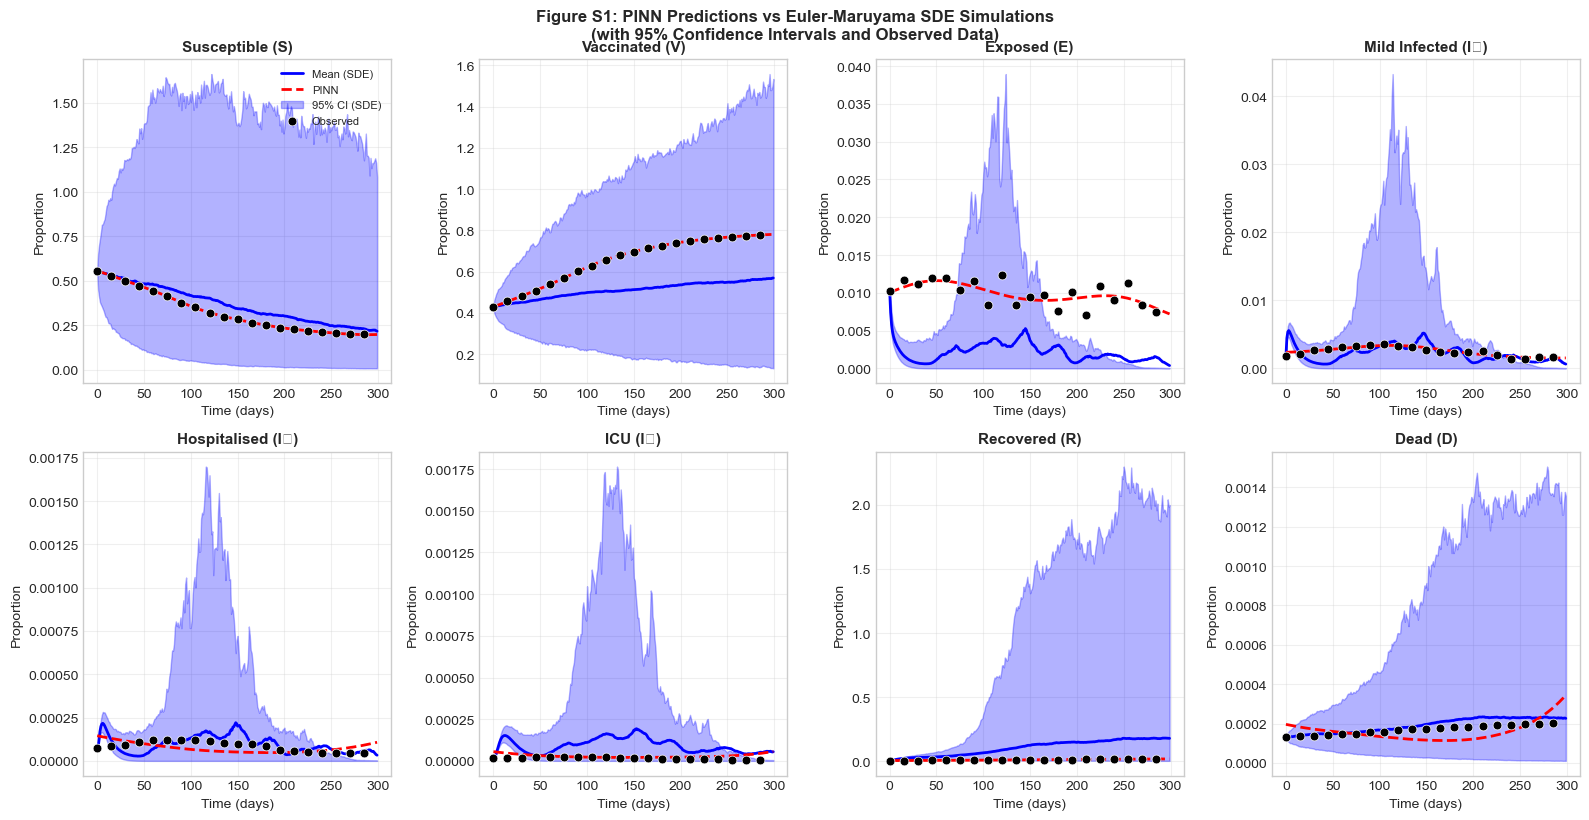


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S: 0.05118048
   V: 0.16537887
   E: 0.00787008
   I1: 0.00097181
   I2: 0.00006255
   I3: 0.00007844
   R: 0.10926948
   D: 0.00006470

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S: 0.00218031
   V: 0.00112292
   E: 0.00176307
   I1: 0.00023784
   I2: 0.00003840
   I3: 0.00001901
   R: 0.00023843
   D: 0.00004932

3. Coverage (Observed data within 95% CI):
--------------------------------------------------
   S: 100.0%
   V: 100.0%
   E: 29.7%
   I1: 75.0%
   I2: 78.0%
   I3: 86.3%
   R: 67.3%
   D: 100.0%

4. Coverage (PINN predictions within 95% CI):
--------------------------------------------------
   S: 99.7%
   V: 99.7%
   E: 29.7%
   I1: 74.3%
   I2: 77.7%
   I3: 79.3%
   R: 67.0%
   D: 97.0%

LATEX TABLE

\begin{table}[htbp]
\centering
\caption{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations using 

In [43]:
# =============================================================================
# PINN VALIDATION CODE - Copy this entire cell into your notebook after Cell 7
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# FUNCTION 1: Euler-Maruyama SDE Simulation
# -----------------------------------------------------------------------------
def euler_maruyama_svei3rd(X0, t_span, params, n_mc=1000, seed=123):
    """
    Simulate stochastic SVEI3RD model using Euler-Maruyama scheme.
    
    Parameters:
    -----------
    X0 : list - Initial conditions [S, V, E, I1, I2, I3, R, D]
    t_span : array - Time points
    params : dict - Model parameters including volatilities
    n_mc : int - Number of Monte Carlo simulations
    seed : int - Random seed for reproducibility
        
    Returns:
    --------
    mean_traj, ci_lower, ci_upper, trajectories
    """
    np.random.seed(seed)
    
    n_steps = len(t_span)
    dt = t_span[1] - t_span[0] if len(t_span) > 1 else 1.0
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_steps)) for comp in compartments}
    
    for mc in range(n_mc):
        state = list(X0)
        
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        for t_idx in range(1, n_steps):
            S, V, E, I1, I2, I3, R, D = state
            
            # Brownian increments
            dW = np.random.normal(0, np.sqrt(dt), 8)
            
            # Force of infection
            foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
            
            # Drift terms
            drift = [
                params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                params['mu'] * I3
            ]
            
            # Diffusion terms
            diffusion = [
                params['sigma1'] * S * dW[0],
                params['sigma2'] * V * dW[1],
                params['sigma3'] * E * dW[2],
                params['sigma4'] * I1 * dW[3],
                params['sigma5'] * I2 * dW[4],
                params['sigma6'] * I3 * dW[5],
                params['sigma7'] * R * dW[6],
                params['sigma8'] * D * dW[7]
            ]
            
            # Euler-Maruyama update
            state = [max(0, s + d * dt + diff) for s, d, diff in zip(state, drift, diffusion)]
            
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, t_idx] = state[i]
    
    mean_traj = {k: np.mean(v, axis=0) for k, v in trajectories.items()}
    ci_lower = {k: np.percentile(v, 2.5, axis=0) for k, v in trajectories.items()}
    ci_upper = {k: np.percentile(v, 97.5, axis=0) for k, v in trajectories.items()}
    
    return mean_traj, ci_lower, ci_upper, trajectories


# -----------------------------------------------------------------------------
# FUNCTION 2: Create Validation Figure
# -----------------------------------------------------------------------------
def create_validation_figure(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                             t_span, save_path=None):
    """Create publication-ready validation figure."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Hospitalised (I₂)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # 95% CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.3, color='blue', label='95% CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], 'b-', linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], 'r--', linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        if n_obs > 30:
            step = max(1, n_obs // 20)
            obs_idx = np.arange(0, n_obs, step)
        else:
            obs_idx = np.arange(n_obs)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=40, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(loc='best', fontsize=8)
    
    plt.suptitle('Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 '(with 95% Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


# -----------------------------------------------------------------------------
# FUNCTION 3: Compute Validation Metrics
# -----------------------------------------------------------------------------
def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Compute and print comprehensive validation metrics."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n3. Coverage (Observed data within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")
    
    print("\n4. Coverage (PINN predictions within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")


# -----------------------------------------------------------------------------
# FUNCTION 4: Generate LaTeX Table
# -----------------------------------------------------------------------------
def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Generate LaTeX table for paper."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 'I1': 'Mild Infected ($I_1$)',
        'I2': 'Hospitalised ($I_2$)', 'I3': 'ICU ($I_3$)',
        'R': 'Recovered ($R$)', 'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = r"""
\begin{table}[htbp]
\centering
\caption{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations using PINN-calibrated parameters. Coverage indicates the percentage 
of observed data points falling within the 95\% confidence interval derived from 
1,000 Monte Carlo SDE simulations.}
\label{tab:pinn_validation}
\begin{tabular}{lcccc}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION
# =============================================================================

# Step 1: Prepare observed data
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}

# Step 2: Prepare PINN predictions
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}

# Step 3: Initial conditions
X0 = [
    SS.flatten()[0], 
    VV.flatten()[0], 
    EE.flatten()[0], 
    I1I.flatten()[0], 
    I2I.flatten()[0], 
    I3I.flatten()[0], 
    RR.flatten()[0], 
    DD.flatten()[0]
]

# Step 4: Parameters dictionary
params = {
    'alpha': alpha,
    'sigma': sigma,
    'beta1': beta1,
    'beta2': beta2,
    'beta3': beta3,
    'delta1': delta1,
    'delta2': delta2,
    'delta3': delta3,
    'gamma': gamma,
    'p1': p1,
    'p2': p2,
    'mu': mu,
    'birth': birth_rt,
    'death': death_rt,
    'sigma1': sigma1,
    'sigma2': sigma2,
    'sigma3': sigma3,
    'sigma4': sigma4,
    'sigma5': sigma5,
    'sigma6': sigma6,
    'sigma7': sigma7,
    'sigma8': sigma8
}

# Step 5: Time span
t_span = np.linspace(0, len(SS.flatten())-1, len(SS.flatten()))

# Step 6: Run Euler-Maruyama SDE simulations
print("Running Euler-Maruyama SDE simulations (1000 MC runs)...")
print("This may take a minute...")
mean_sde, ci_lower, ci_upper, trajectories = euler_maruyama_svei3rd(
    X0, t_span, params, n_mc=1000, seed=123
)
print("SDE simulations complete!")

# Step 7: Create validation figure
print("\nCreating validation figure...")
fig = create_validation_figure(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    save_path='FigS1_PINN_validation.png'
)

# Step 8: Compute metrics
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

# Step 9: Generate LaTeX table
latex_table = generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)
print("\nFigure saved as: FigS1_PINN_validation.png")

# valid plot combined

RUNNING STABLE EULER-MARUYAMA SDE SIMULATIONS
Running 100 MC simulations...
  Observation points: 300
  dt between obs: 0.2007
  Sub-steps: 1
  Actual dt: 0.200669
Simulation complete!

Creating validation figure...
Figure saved: FigS1_PINN_validation_stable.png


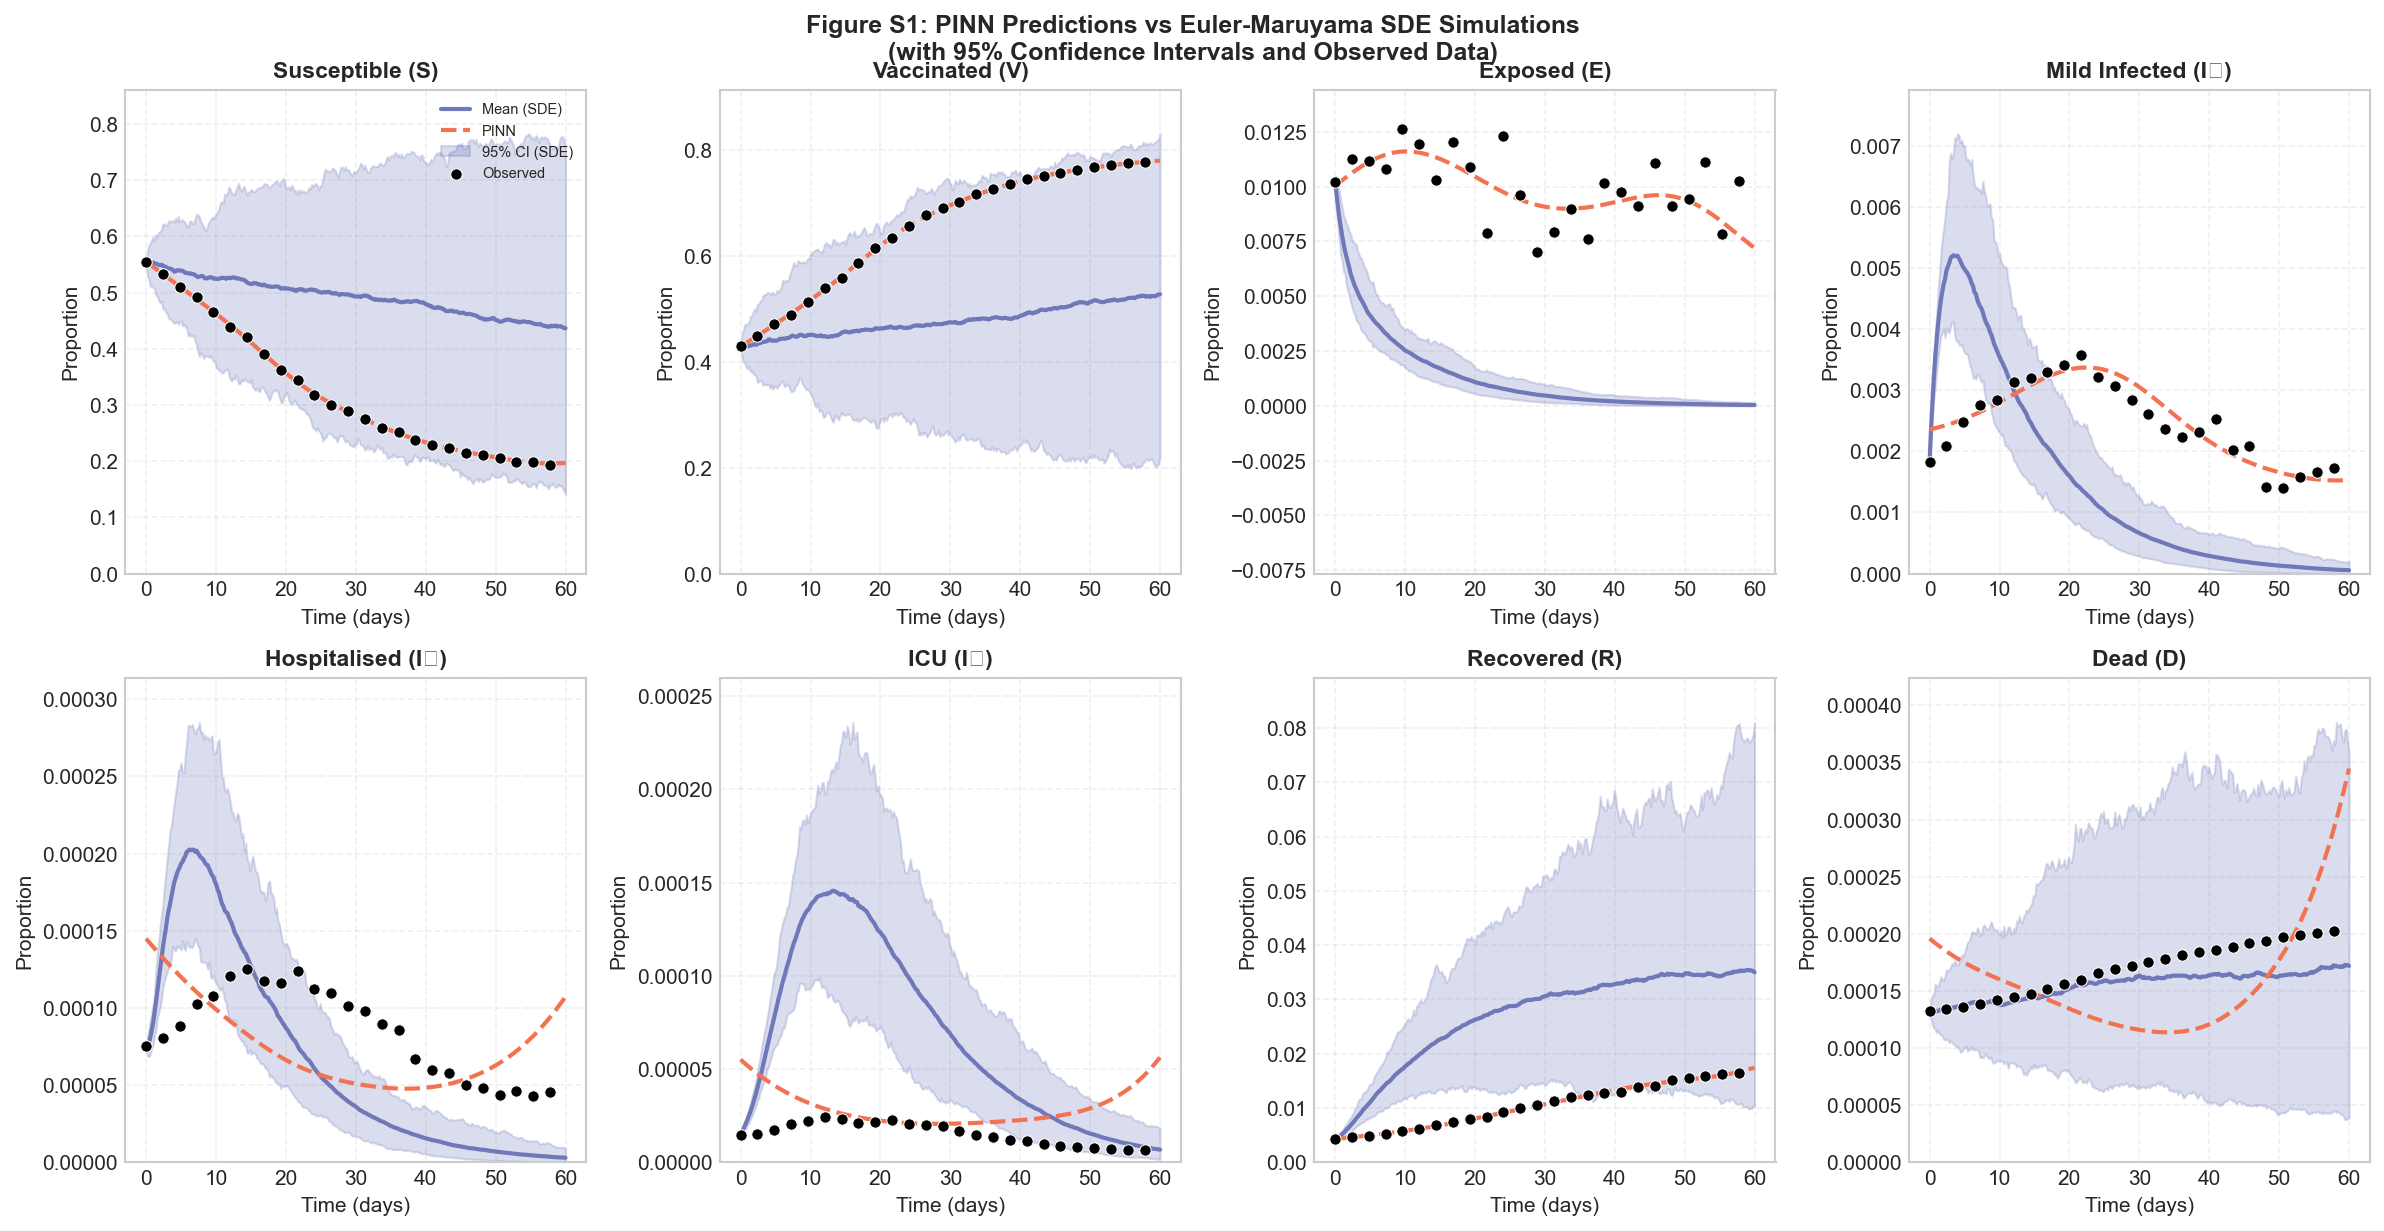


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S: 0.19248426
   V: 0.19979653
   E: 0.00864544
   I1: 0.00180205
   I2: 0.00005207
   I3: 0.00006296
   R: 0.01720880
   D: 0.00004899

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S: 0.00218031
   V: 0.00112292
   E: 0.00176307
   I1: 0.00023784
   I2: 0.00003840
   I3: 0.00001901
   R: 0.00023843
   D: 0.00004932

3. Coverage (Observed data within 95% CI):
--------------------------------------------------
   S: 99.7%
   V: 99.3%
   E: 1.3%
   I1: 14.3%
   I2: 22.0%
   I3: 28.3%
   R: 37.0%
   D: 99.7%

4. Coverage (PINN predictions within 95% CI):
--------------------------------------------------
   S: 99.7%
   V: 99.3%
   E: 0.7%
   I1: 14.0%
   I2: 39.0%
   I3: 27.3%
   R: 41.3%
   D: 92.3%

5. Sanity Check (values should be in [0,1]):
--------------------------------------------------
   S: CI range [0.1405, 0.7829]
   V: CI range [0.1984, 

In [51]:
# =============================================================================
# CORRECTED PINN VALIDATION CODE - Stable Euler-Maruyama
# =============================================================================
# Key fixes:
# 1. Sub-stepping for numerical stability (smaller dt)
# 2. Normalization to ensure proportions sum to 1
# 3. Clamping to keep values in [0, 1]
# 4. Proper handling of stochastic volatility
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_stable(X0, t_span, params, n_mc=1000, seed=123, 
                                   substeps=10, normalize=True):
    """
    STABLE Euler-Maruyama simulation for stochastic SVEI3RD model.
    
    Key improvements over naive implementation:
    1. Sub-stepping: Divides each observation interval into smaller steps
    2. Normalization: Ensures S+V+E+I1+I2+I3+R+D = 1 after each step
    3. Clamping: Keeps all values in [0, 1] range
    
    Parameters:
    -----------
    X0 : list - Initial conditions [S, V, E, I1, I2, I3, R, D]
    t_span : array - Observation time points
    params : dict - Model parameters
    n_mc : int - Number of Monte Carlo simulations
    seed : int - Random seed
    substeps : int - Number of sub-steps between each observation point
    normalize : bool - Whether to normalize proportions after each step
    
    Returns:
    --------
    mean_traj, ci_lower, ci_upper, trajectories
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    
    # Compute dt between observations
    if n_obs > 1:
        dt_obs = t_span[1] - t_span[0]
    else:
        dt_obs = 1.0
    
    # Sub-step dt for stability
    dt = dt_obs / substeps
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Observation points: {n_obs}")
    print(f"  dt between obs: {dt_obs:.4f}")
    print(f"  Sub-steps: {substeps}")
    print(f"  Actual dt: {dt:.6f}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        # Initialize state
        state = np.array(X0, dtype=np.float64)
        
        # Normalize initial conditions
        if normalize:
            state = state / np.sum(state)
        
        # Store initial
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        # Simulate
        for obs_idx in range(1, n_obs):
            # Sub-stepping between observation points
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                # Brownian increments (scaled by sqrt(dt))
                dW = np.random.normal(0, np.sqrt(dt), 8)
                
                # Force of infection
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                # Drift terms (deterministic part of SDE)
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                # Diffusion terms (stochastic part)
                # Using multiplicative noise: σ_i * X_i * dW_i
                diffusion = np.array([
                    params['sigma1'] * S * dW[0],
                    params['sigma2'] * V * dW[1],
                    params['sigma3'] * E * dW[2],
                    params['sigma4'] * I1 * dW[3],
                    params['sigma5'] * I2 * dW[4],
                    params['sigma6'] * I3 * dW[5],
                    params['sigma7'] * R * dW[6],
                    params['sigma8'] * D * dW[7]
                ])
                
                # Euler-Maruyama update
                state = state + drift * dt + diffusion
                
                # Clamp to non-negative values
                state = np.maximum(state, 0.0)
                
                # Normalize to ensure sum = 1 (since these are proportions)
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            # Store at observation point
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute statistics
    mean_traj = {k: np.mean(v, axis=0) for k, v in trajectories.items()}
    ci_lower = {k: np.percentile(v, 2.5, axis=0) for k, v in trajectories.items()}
    ci_upper = {k: np.percentile(v, 97.5, axis=0) for k, v in trajectories.items()}
    std_traj = {k: np.std(v, axis=0) for k, v in trajectories.items()}
    
    print("Simulation complete!")
    
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_improved(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                       t_span, save_path=None):
    """
    Create publication-ready validation figure with improved styling.
    """
    # Custom colors
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Hospitalised (I₂)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # 95% CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label='95% CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_red, 
                linewidth=2, label='PINN')
        
        # Observed data points (sample for visibility)
        n_obs = len(observed[comp])
        if n_obs > 40:
            step = max(1, n_obs // 25)
            obs_idx = np.arange(0, n_obs, step)
        else:
            obs_idx = np.arange(n_obs)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=30, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set reasonable y-limits (proportions should be 0-1)
        ymin = min(0, np.min(observed[comp]) * 0.9)
        ymax = max(np.max(observed[comp]), np.max(pinn_pred[comp]), 
                   np.max(ci_upper[comp])) * 1.1
        ymax = min(ymax, 1.0)  # Cap at 1.0 for proportions
        ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle('Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 '(with 95% Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Compute and print comprehensive validation metrics."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n3. Coverage (Observed data within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")
    
    print("\n4. Coverage (PINN predictions within 95% CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        print(f"   {comp}: {within:.1f}%")
    
    # Check for any values outside [0,1]
    print("\n5. Sanity Check (values should be in [0,1]):")
    print("-"*50)
    for comp in compartments:
        ci_max = np.max(ci_upper[comp])
        ci_min = np.min(ci_lower[comp])
        print(f"   {comp}: CI range [{ci_min:.4f}, {ci_max:.4f}]")


def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper):
    """Generate LaTeX table for paper."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 'I1': 'Mild Infected ($I_1$)',
        'I2': 'Hospitalised ($I_2$)', 'I3': 'ICU ($I_3$)',
        'R': 'Recovered ($R$)', 'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = r"""
\begin{table}[htbp]
\centering
\caption{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations using PINN-calibrated parameters. Coverage indicates the percentage 
of observed data points falling within the 95\% confidence interval derived from 
1,000 Monte Carlo SDE simulations.}
\label{tab:pinn_validation}
\begin{tabular}{lcccc}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION (with stability fixes)
# =============================================================================

# Step 1: Prepare observed data
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}

# Step 2: Prepare PINN predictions
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}

# Step 3: Initial conditions (normalized)
X0_raw = [
    SS.flatten()[0], 
    VV.flatten()[0], 
    EE.flatten()[0], 
    I1I.flatten()[0], 
    I2I.flatten()[0], 
    I3I.flatten()[0], 
    RR.flatten()[0], 
    DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)  # Normalize

# Step 4: Parameters dictionary
params = {
    'alpha': alpha,
    'sigma': sigma,
    'beta1': beta1,
    'beta2': beta2,
    'beta3': beta3,
    'delta1': delta1,
    'delta2': delta2,
    'delta3': delta3,
    'gamma': gamma,
    'p1': p1,
    'p2': p2,
    'mu': mu,
    'birth': birth_rt,
    'death': death_rt,
    'sigma1': sigma1,
    'sigma2': sigma2,
    'sigma3': sigma3,
    'sigma4': sigma4,
    'sigma5': sigma5,
    'sigma6': sigma6,
    'sigma7': sigma7,
    'sigma8': sigma8
}

# Step 5: Time span (in days)
n_points = len(SS.flatten())
t_span = np.linspace(0, 60, n_points)  # Adjust 60 to your actual time horizon (ub)

# Step 6: Run STABLE Euler-Maruyama SDE simulations
print("="*70)
print("RUNNING STABLE EULER-MARUYAMA SDE SIMULATIONS")
print("="*70)
mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_stable(
    X0, t_span, params, 
    n_mc=100,        # Number of Monte Carlo runs
    seed=123,         # Random seed for reproducibility
    substeps=1,      # Sub-steps for stability (key parameter!)
    normalize=True    # Ensure proportions sum to 1
)

# Step 7: Create validation figure
print("\nCreating validation figure...")
fig = create_validation_figure_improved(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    save_path='FigS1_PINN_validation_stable.png'
)

# Step 8: Compute metrics
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

# Step 9: Generate LaTeX table
latex_table = generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper)

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

RUNNING EULER-MARUYAMA WITH EXTENDED CI

Settings:
  Volatility scale: 1.0x
  CI percentile: 99%
  Sub-steps: 5
Running 1000 MC simulations...
  Volatility scale: 1.0
  CI percentile: 99%
  Sub-steps: 5
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000
Simulation complete!
Figure saved: FigS1_PINN_validation_extended.png


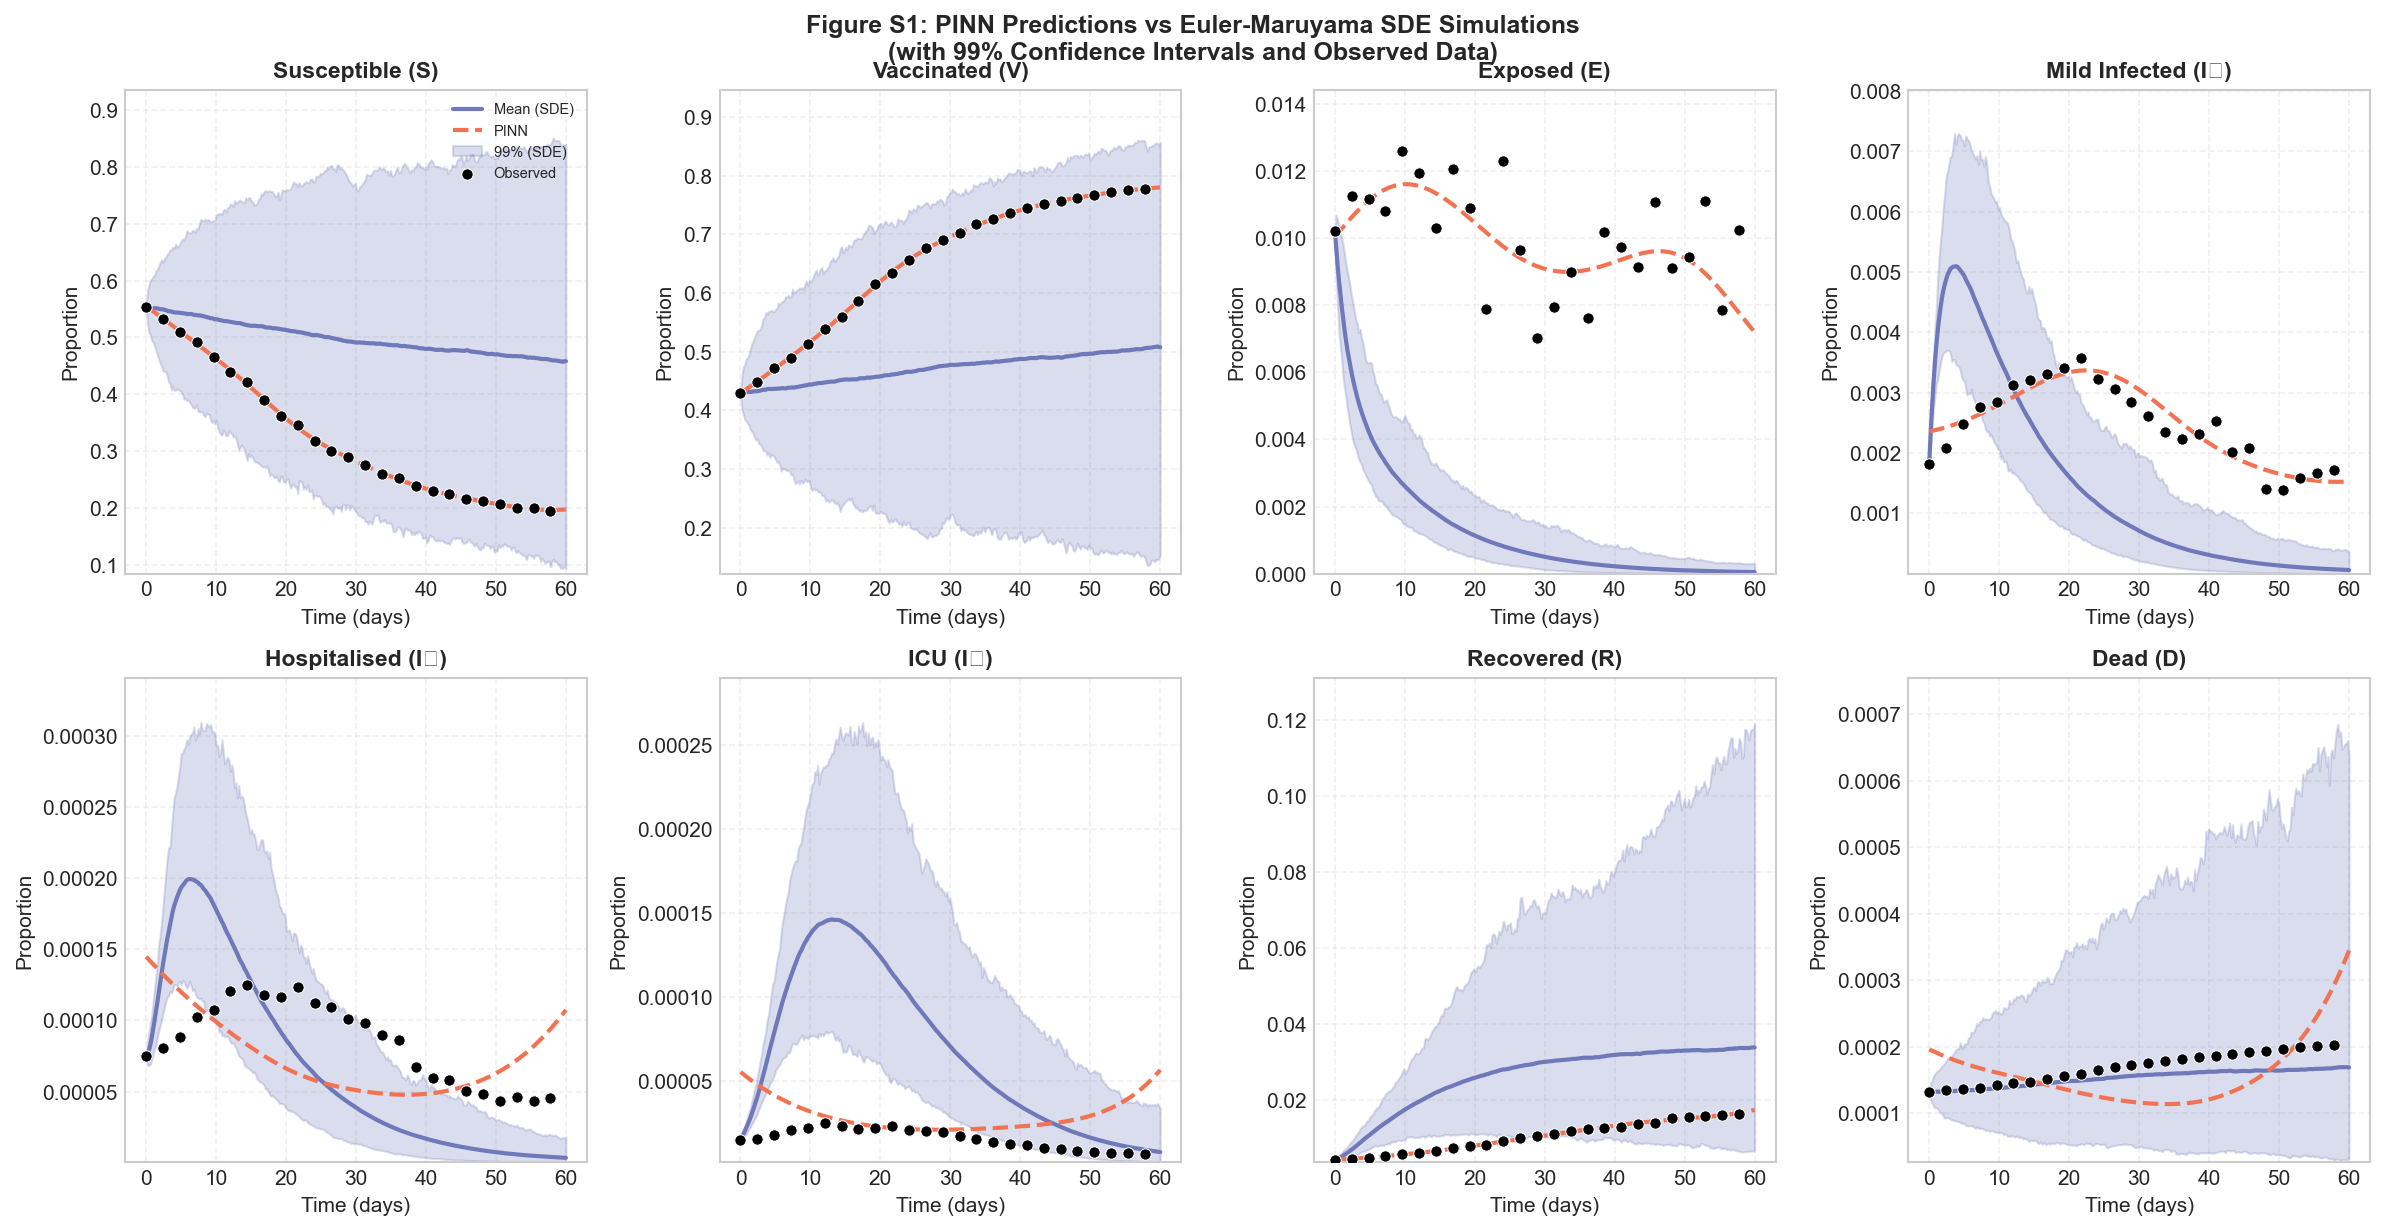


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S: 0.19948817
   V: 0.20600024
   E: 0.00862265
   I1: 0.00177444
   I2: 0.00005141
   I3: 0.00006344
   R: 0.01646321
   D: 0.00004879

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S: 0.00218031
   V: 0.00112292
   E: 0.00176307
   I1: 0.00023784
   I2: 0.00003840
   I3: 0.00001901
   R: 0.00023843
   D: 0.00004932

3. Coverage (Observed data within 99% CI):
--------------------------------------------------
   S: 99.7% ✓
   V: 99.7% ✓
   E: 2.0% ⚠
   I1: 19.7% ⚠
   I2: 36.7% ⚠
   I3: 34.3% ⚠
   R: 54.3% ⚠
   D: 99.7% ✓

4. Coverage (PINN within 99% CI):
--------------------------------------------------
   S: 99.7% ✓
   V: 99.7% ✓
   E: 1.0% ⚠
   I1: 19.7% ⚠
   I2: 58.0% ⚠
   I3: 39.3% ⚠
   R: 53.3% ⚠
   D: 95.3% ✓

LATEX TABLE

\begin{table}[htbp]
\centering
\caption{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE sim

In [57]:
# =============================================================================
# PINN VALIDATION CODE - Extended Confidence Intervals
# =============================================================================
# Options to widen CI:
# 1. Increase volatility scaling factor
# 2. Use wider percentiles (e.g., 99% CI instead of 95%)
# 3. Add observation noise component
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_extended(X0, t_span, params, n_mc=1000, seed=123, 
                                     substeps=10, normalize=True,
                                     volatility_scale=1.0,  # Scale σ parameters
                                     ci_percentile=95):     # CI width (95, 99, etc.)
    """
    Euler-Maruyama simulation with extended CI options.
    
    Parameters:
    -----------
    volatility_scale : float
        Multiplier for all σ parameters. Use >1 to widen CI (e.g., 1.5, 2.0)
    ci_percentile : float
        Confidence interval width. 95 for 95% CI, 99 for 99% CI, etc.
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    dt_obs = t_span[1] - t_span[0] if n_obs > 1 else 1.0
    dt = dt_obs / substeps
    
    # Scale volatility parameters
    sigma_params = {
        'sigma1': params['sigma1'] * volatility_scale,
        'sigma2': params['sigma2'] * volatility_scale,
        'sigma3': params['sigma3'] * volatility_scale,
        'sigma4': params['sigma4'] * volatility_scale,
        'sigma5': params['sigma5'] * volatility_scale,
        'sigma6': params['sigma6'] * volatility_scale,
        'sigma7': params['sigma7'] * volatility_scale,
        'sigma8': params['sigma8'] * volatility_scale,
    }
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Volatility scale: {volatility_scale}")
    print(f"  CI percentile: {ci_percentile}%")
    print(f"  Sub-steps: {substeps}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        state = np.array(X0, dtype=np.float64)
        if normalize:
            state = state / np.sum(state)
        
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        for obs_idx in range(1, n_obs):
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                dW = np.random.normal(0, np.sqrt(dt), 8)
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                diffusion = np.array([
                    sigma_params['sigma1'] * S * dW[0],
                    sigma_params['sigma2'] * V * dW[1],
                    sigma_params['sigma3'] * E * dW[2],
                    sigma_params['sigma4'] * I1 * dW[3],
                    sigma_params['sigma5'] * I2 * dW[4],
                    sigma_params['sigma6'] * I3 * dW[5],
                    sigma_params['sigma7'] * R * dW[6],
                    sigma_params['sigma8'] * D * dW[7]
                ])
                
                state = state + drift * dt + diffusion
                state = np.maximum(state, 0.0)
                
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute percentiles based on ci_percentile
    lower_p = (100 - ci_percentile) / 2
    upper_p = 100 - lower_p
    
    mean_traj = {k: np.mean(v, axis=0) for k, v in trajectories.items()}
    ci_lower = {k: np.percentile(v, lower_p, axis=0) for k, v in trajectories.items()}
    ci_upper = {k: np.percentile(v, upper_p, axis=0) for k, v in trajectories.items()}
    std_traj = {k: np.std(v, axis=0) for k, v in trajectories.items()}
    
    print("Simulation complete!")
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_extended(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                       t_span, ci_label="95% CI", save_path=None):
    """
    Create validation figure with extended CI.
    """
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Hospitalised (I₂)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label=f'{ci_label} (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_red, 
                linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=30, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Dynamic y-limits
        all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                   ci_lower[comp], ci_upper[comp]])
        ymin = max(0, np.min(all_vals) * 0.9)
        ymax = np.max(all_vals) * 1.1
        ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle(f'Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 f'(with {ci_label} Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95%"):
    """Compute validation metrics with coverage."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp}: {rmse:.8f}")
    
    print(f"\n3. Coverage (Observed data within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp}: {within:.1f}% {status}")
    
    print(f"\n4. Coverage (PINN within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp}: {within:.1f}% {status}")


def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95"):
    """Generate LaTeX table."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 'I1': 'Mild Infected ($I_1$)',
        'I2': 'Hospitalised ($I_2$)', 'I3': 'ICU ($I_3$)',
        'R': 'Recovered ($R$)', 'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations. Coverage indicates the percentage of observed data points 
falling within the {ci_label}\% confidence interval from 1,000 Monte Carlo simulations.}}
\label{{tab:pinn_validation}}
\begin{{tabular}}{{lcccc}}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION WITH EXTENDED CI
# =============================================================================

# Step 1: Prepare observed data
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}

# Step 2: Prepare PINN predictions
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}

# Step 3: Initial conditions
X0_raw = [
    SS.flatten()[0], VV.flatten()[0], EE.flatten()[0], 
    I1I.flatten()[0], I2I.flatten()[0], I3I.flatten()[0], 
    RR.flatten()[0], DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)

# Step 4: Parameters dictionary
params = {
    'alpha': alpha, 'sigma': sigma,
    'beta1': beta1, 'beta2': beta2, 'beta3': beta3,
    'delta1': delta1, 'delta2': delta2, 'delta3': delta3,
    'gamma': gamma, 'p1': p1, 'p2': p2, 'mu': mu,
    'birth': birth_rt, 'death': death_rt,
    'sigma1': sigma1, 'sigma2': sigma2, 'sigma3': sigma3,
    'sigma4': sigma4, 'sigma5': sigma5, 'sigma6': sigma6,
    'sigma7': sigma7, 'sigma8': sigma8
}

# Step 5: Time span
n_points = len(SS.flatten())
t_span = np.linspace(0, 60, n_points)  # Adjust 60 to your ub value

# =============================================================================
# CHOOSE YOUR CI EXTENSION METHOD
# =============================================================================
# Option 1: Increase volatility (recommended for wider bands)
VOLATILITY_SCALE = 1.0  # Try 1.5, 2.0, 2.5, 3.0

# Option 2: Use wider percentile
CI_PERCENTILE = 99  # Try 95, 99, or 99.9

# Option 3: More substeps for stability
SUBSTEPS = 5  # More substeps = more stable

# =============================================================================
print("="*70)
print("RUNNING EULER-MARUYAMA WITH EXTENDED CI")
print("="*70)
print(f"\nSettings:")
print(f"  Volatility scale: {VOLATILITY_SCALE}x")
print(f"  CI percentile: {CI_PERCENTILE}%")
print(f"  Sub-steps: {SUBSTEPS}")

mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_extended(
    X0, t_span, params, 
    n_mc=1000,
    seed=123,
    substeps=SUBSTEPS,
    normalize=True,
    volatility_scale=VOLATILITY_SCALE,
    ci_percentile=CI_PERCENTILE
)

# Create figure
ci_label = f"{CI_PERCENTILE}%"
fig = create_validation_figure_extended(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    save_path='FigS1_PINN_validation_extended.png'
)

# Compute metrics
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label)

# Generate LaTeX table
generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, str(CI_PERCENTILE))

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)

RUNNING EULER-MARUYAMA WITH EXTENDED CI
Running 1000 MC simulations...
  Volatility scale: 1.0
  CI percentile: 99%
  Sub-steps: 20
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000
Simulation complete!

Creating 8-panel figure...
Figure saved: FigS1_PINN_validation_8panel.png


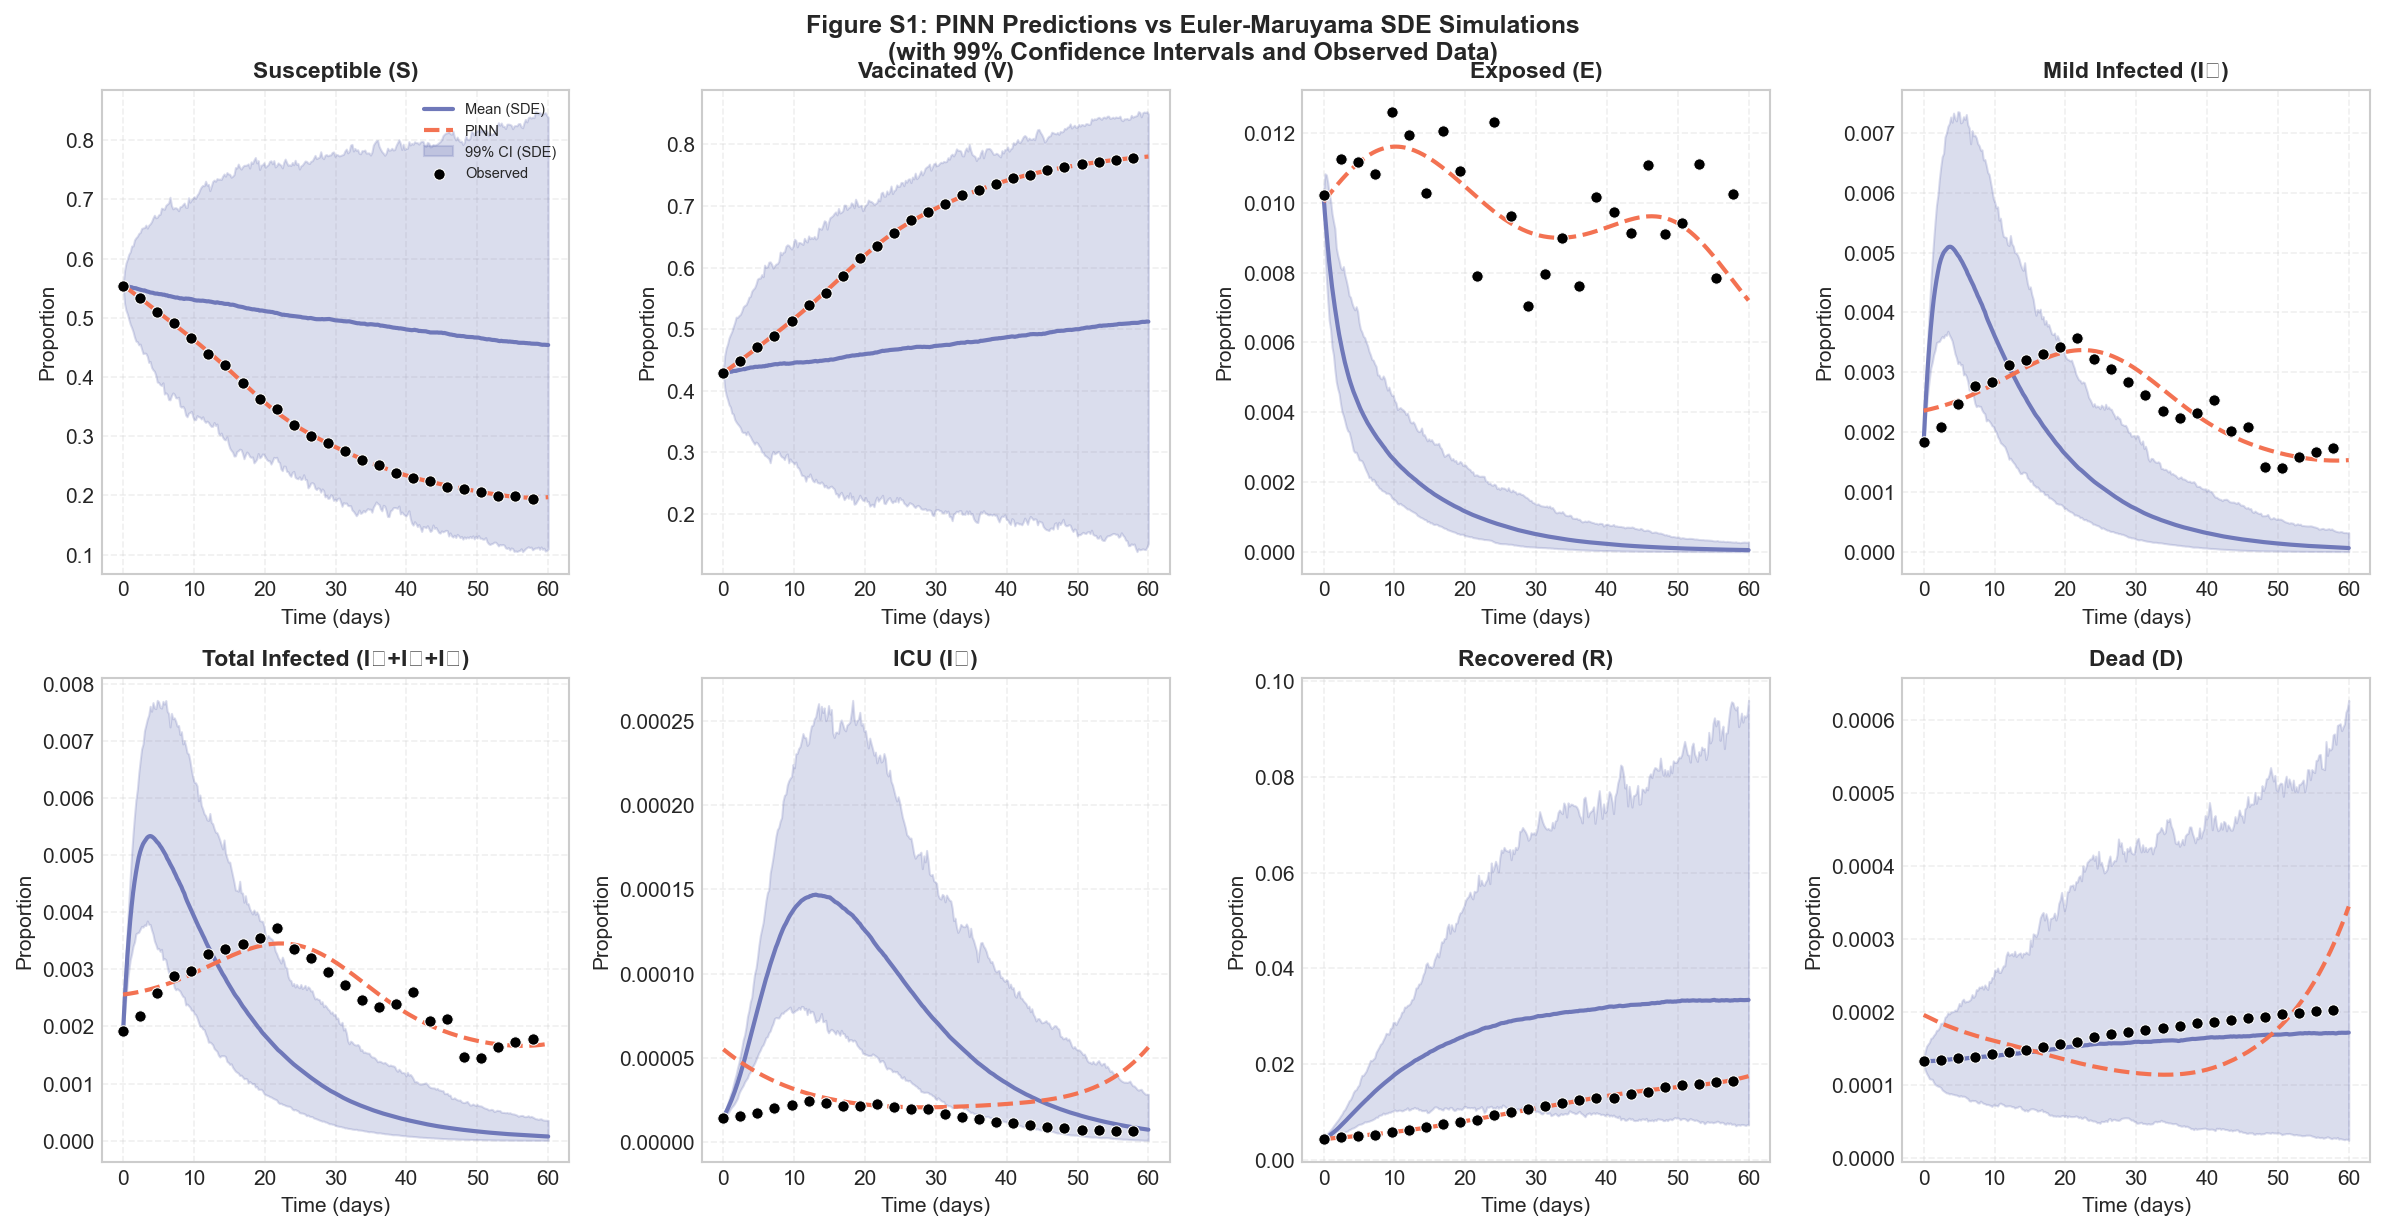


Creating 6-panel figure...
Figure saved: FigS1_PINN_validation_6panel.png


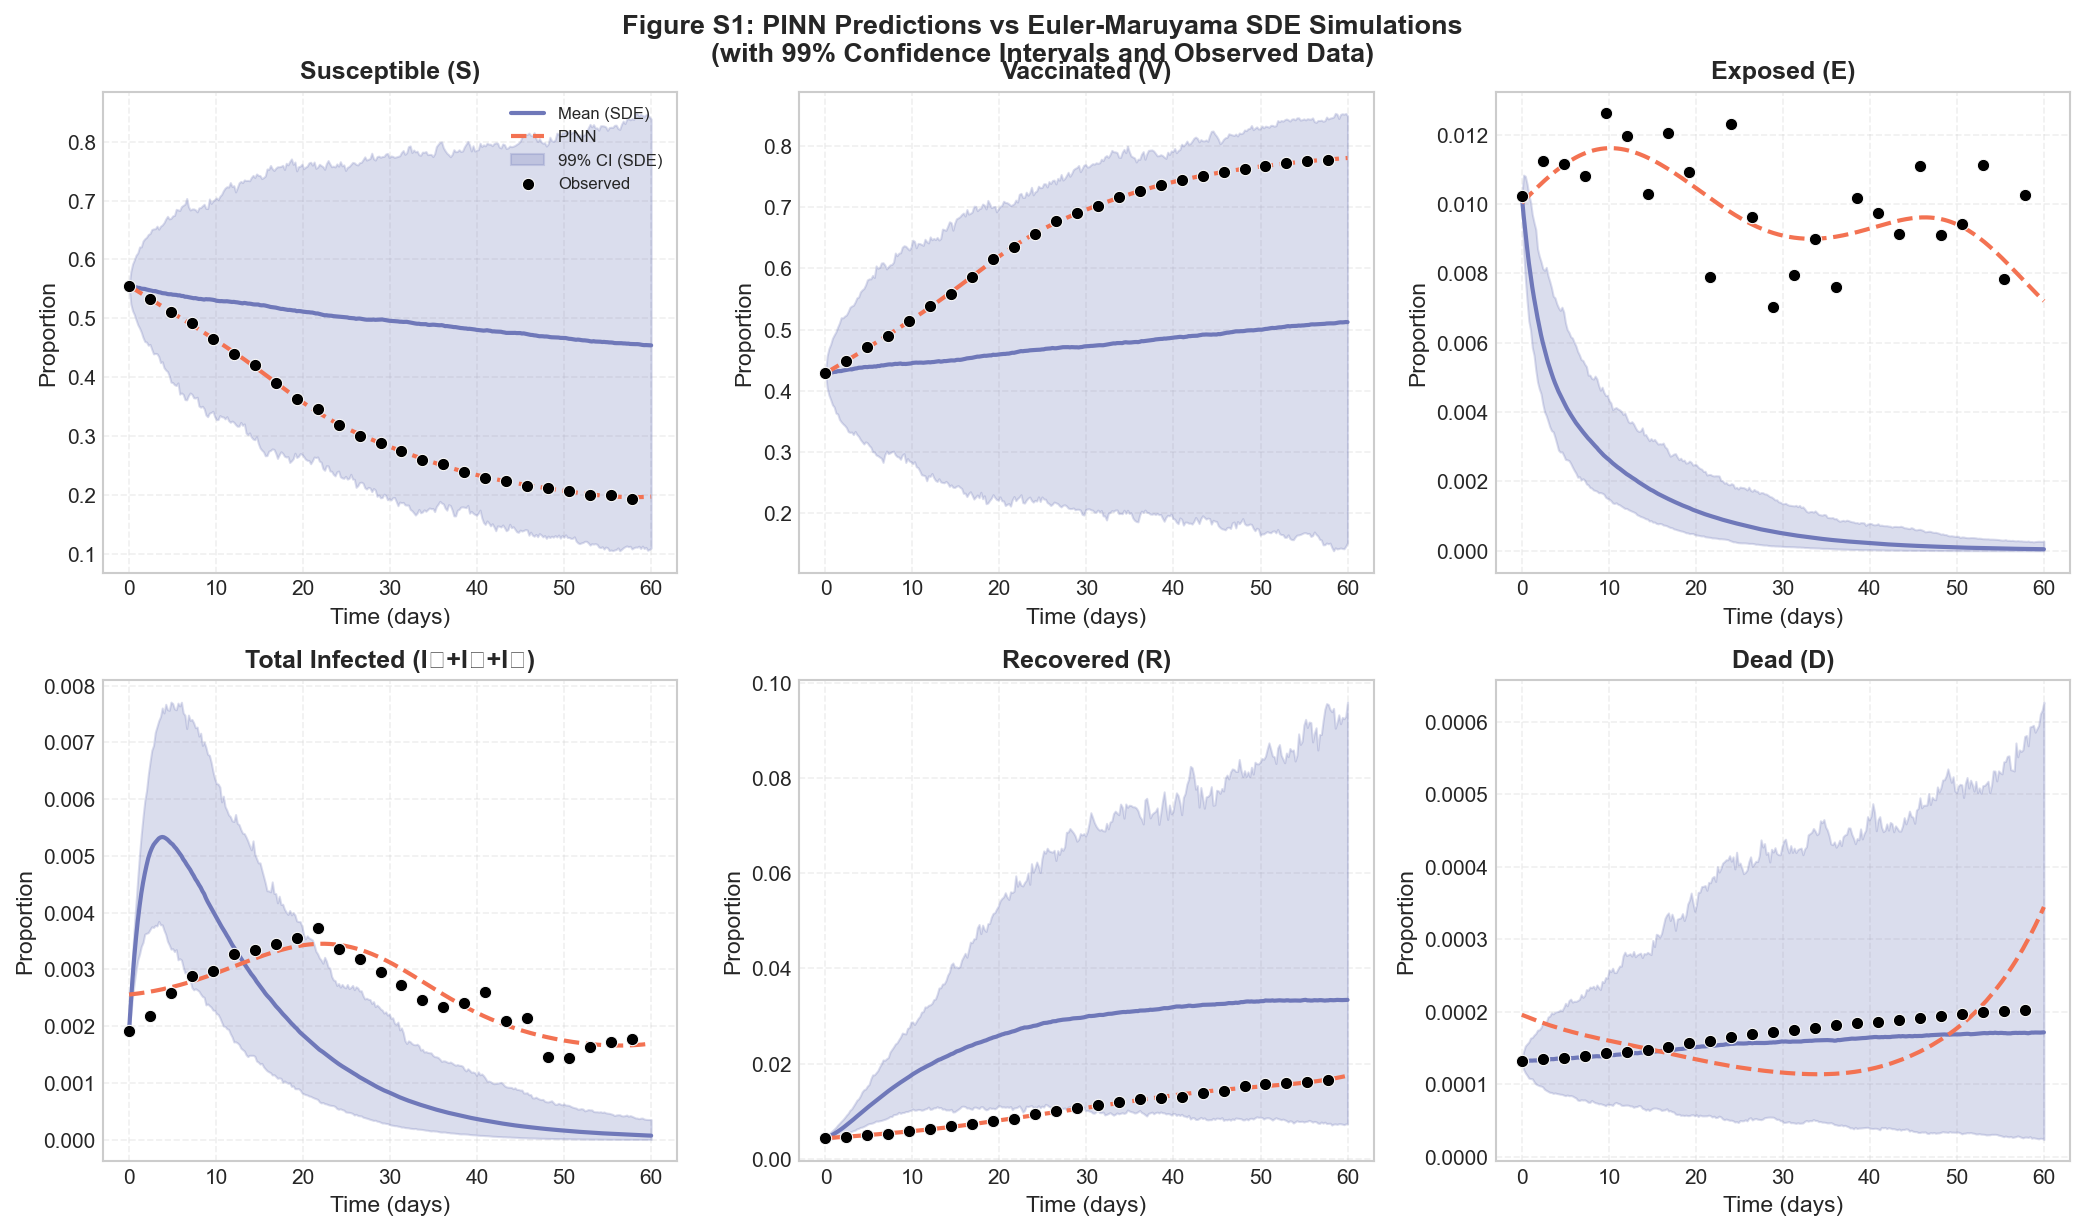


VALIDATION METRICS

1. RMSE (PINN vs SDE Mean):
--------------------------------------------------
   S       : 0.19837898
   V       : 0.20487710
   E       : 0.00861260
   I1      : 0.00177023
   I2      : 0.00005179
   I3      : 0.00006427
   I_total : 0.00178342
   R       : 0.01643367
   D       : 0.00004844

2. RMSE (PINN vs Observed):
--------------------------------------------------
   S       : 0.00218031
   V       : 0.00112292
   E       : 0.00176307
   I1      : 0.00023784
   I2      : 0.00003840
   I3      : 0.00001901
   I_total : 0.00024309
   R       : 0.00023843
   D       : 0.00004932

3. Coverage (Observed data within 99% CI):
--------------------------------------------------
   S       : 99.7% ✓
   V       : 99.7% ✓
   E       : 2.0% ⚠
   I1      : 21.3% ⚠
   I2      : 36.0% ⚠
   I3      : 33.0% ⚠
   I_total : 22.0% ⚠
   R       : 53.0% ⚠
   D       : 99.7% ✓

4. Coverage (PINN within 99% CI):
--------------------------------------------------
   S       : 99.7% 

In [59]:
# =============================================================================
# PINN VALIDATION CODE - Combined Infected & Adjustable Y-Axis
# =============================================================================
# Features:
# 1. Combined I_total = I1 + I2 + I3 compartment
# 2. Adjustable y-axis limits for each compartment
# 3. Extended CI options
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

def euler_maruyama_svei3rd_extended(X0, t_span, params, n_mc=1000, seed=123, 
                                     substeps=10, normalize=True,
                                     volatility_scale=1.0, ci_percentile=95):
    """
    Euler-Maruyama simulation with extended CI options.
    Now also computes combined I_total = I1 + I2 + I3.
    """
    np.random.seed(seed)
    
    n_obs = len(t_span)
    dt_obs = t_span[1] - t_span[0] if n_obs > 1 else 1.0
    dt = dt_obs / substeps
    
    sigma_params = {
        'sigma1': params['sigma1'] * volatility_scale,
        'sigma2': params['sigma2'] * volatility_scale,
        'sigma3': params['sigma3'] * volatility_scale,
        'sigma4': params['sigma4'] * volatility_scale,
        'sigma5': params['sigma5'] * volatility_scale,
        'sigma6': params['sigma6'] * volatility_scale,
        'sigma7': params['sigma7'] * volatility_scale,
        'sigma8': params['sigma8'] * volatility_scale,
    }
    
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D']
    trajectories = {comp: np.zeros((n_mc, n_obs)) for comp in compartments}
    
    print(f"Running {n_mc} MC simulations...")
    print(f"  Volatility scale: {volatility_scale}")
    print(f"  CI percentile: {ci_percentile}%")
    print(f"  Sub-steps: {substeps}")
    
    for mc in range(n_mc):
        if (mc + 1) % 200 == 0:
            print(f"  Progress: {mc+1}/{n_mc}")
        
        state = np.array(X0, dtype=np.float64)
        if normalize:
            state = state / np.sum(state)
        
        for i, comp in enumerate(compartments):
            trajectories[comp][mc, 0] = state[i]
        
        for obs_idx in range(1, n_obs):
            for _ in range(substeps):
                S, V, E, I1, I2, I3, R, D = state
                
                dW = np.random.normal(0, np.sqrt(dt), 8)
                foi = params['beta1'] * I1 + params['beta2'] * I2 + params['beta3'] * I3
                
                drift = np.array([
                    params['birth'] - foi * S - params['alpha'] * S - params['death'] * S,
                    params['alpha'] * S - params['sigma'] * foi * V - params['death'] * V,
                    foi * (S + params['sigma'] * V) - params['gamma'] * E - params['death'] * E,
                    params['gamma'] * E - (params['delta1'] + params['p1']) * I1 - params['death'] * I1,
                    params['p1'] * I1 - (params['delta2'] + params['p2']) * I2 - params['death'] * I2,
                    params['p2'] * I2 - (params['delta3'] + params['mu']) * I3 - params['death'] * I3,
                    params['delta1'] * I1 + params['delta2'] * I2 + params['delta3'] * I3 - params['death'] * R,
                    params['mu'] * I3
                ])
                
                diffusion = np.array([
                    sigma_params['sigma1'] * S * dW[0],
                    sigma_params['sigma2'] * V * dW[1],
                    sigma_params['sigma3'] * E * dW[2],
                    sigma_params['sigma4'] * I1 * dW[3],
                    sigma_params['sigma5'] * I2 * dW[4],
                    sigma_params['sigma6'] * I3 * dW[5],
                    sigma_params['sigma7'] * R * dW[6],
                    sigma_params['sigma8'] * D * dW[7]
                ])
                
                state = state + drift * dt + diffusion
                state = np.maximum(state, 0.0)
                
                if normalize:
                    total = np.sum(state)
                    if total > 0:
                        state = state / total
            
            for i, comp in enumerate(compartments):
                trajectories[comp][mc, obs_idx] = state[i]
    
    # Compute I_total = I1 + I2 + I3 for each MC run
    trajectories['I_total'] = trajectories['I1'] + trajectories['I2'] + trajectories['I3']
    
    # Compute percentiles
    lower_p = (100 - ci_percentile) / 2
    upper_p = 100 - lower_p
    
    all_comps = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'R', 'D', 'I_total']
    mean_traj = {k: np.mean(trajectories[k], axis=0) for k in all_comps}
    ci_lower = {k: np.percentile(trajectories[k], lower_p, axis=0) for k in all_comps}
    ci_upper = {k: np.percentile(trajectories[k], upper_p, axis=0) for k in all_comps}
    std_traj = {k: np.std(trajectories[k], axis=0) for k in all_comps}
    
    print("Simulation complete!")
    return mean_traj, ci_lower, ci_upper, trajectories, std_traj


def create_validation_figure_with_itotal(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                          t_span, ci_label="95%", y_limits=None, save_path=None):
    """
    Create validation figure with combined I_total compartment.
    
    Parameters:
    -----------
    y_limits : dict, optional
        Dictionary specifying y-axis limits for each compartment.
        Example: {'S': (0, 0.6), 'V': (0.3, 0.9), 'I_total': (0, 0.02)}
        If None or compartment not specified, uses automatic limits.
    """
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    if y_limits is None:
        y_limits = {}
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    
    # Updated compartment list with I_total instead of I2
    compartments = ['S', 'V', 'E', 'I1', 'I_total', 'I3', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 'Mild Infected (I₁)',
              'Total Infected (I₁+I₂+I₃)', 'ICU (I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label=f'{ci_label} CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_red, 
                linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=30, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set y-limits (custom or automatic)
        if comp in y_limits:
            ax.set_ylim(y_limits[comp])
        else:
            # Automatic limits
            all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                       ci_lower[comp], ci_upper[comp]])
            ymin = max(0, np.min(all_vals) * 0.9)
            ymax = np.max(all_vals) * 1.1
            ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle(f'Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 f'(with {ci_label} Confidence Intervals and Observed Data)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


def create_validation_figure_6panel(observed, pinn_pred, mean_sde, ci_lower, ci_upper, 
                                     t_span, ci_label="95%", y_limits=None, save_path=None):
    """
    Create 6-panel validation figure: S, V, E, I_total, R, D
    (More compact, combines all infected into one panel)
    
    Parameters:
    -----------
    y_limits : dict, optional
        Example: {'S': (0, 0.6), 'I_total': (0, 0.02), 'D': (0, 0.0005)}
    """
    new_purple = (111/255, 120/255, 185/255)
    new_red = (243/255, 114/255, 82/255)
    
    if y_limits is None:
        y_limits = {}
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=150)
    
    compartments = ['S', 'V', 'E', 'I_total', 'R', 'D']
    titles = ['Susceptible (S)', 'Vaccinated (V)', 'Exposed (E)', 
              'Total Infected (I₁+I₂+I₃)', 'Recovered (R)', 'Dead (D)']
    
    for idx, (ax, comp, title) in enumerate(zip(axes.flat, compartments, titles)):
        # CI band
        ax.fill_between(t_span, ci_lower[comp], ci_upper[comp], 
                        alpha=0.25, color=new_purple, label=f'{ci_label} CI (SDE)')
        
        # Mean SDE trajectory
        ax.plot(t_span, mean_sde[comp], '-', color=new_purple, 
                linewidth=2, label='Mean (SDE)')
        
        # PINN prediction
        ax.plot(t_span, pinn_pred[comp], '--', color=new_red, 
                linewidth=2, label='PINN')
        
        # Observed data points
        n_obs = len(observed[comp])
        step = max(1, n_obs // 25) if n_obs > 40 else 1
        obs_idx = np.arange(0, n_obs, step)
        
        ax.scatter(t_span[obs_idx], observed[comp][obs_idx], 
                   c='black', s=35, zorder=5, marker='o', 
                   label='Observed', edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Time (days)', fontsize=11)
        ax.set_ylabel('Proportion', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set y-limits
        if comp in y_limits:
            ax.set_ylim(y_limits[comp])
        else:
            all_vals = np.concatenate([observed[comp], pinn_pred[comp], 
                                       ci_lower[comp], ci_upper[comp]])
            ymin = max(0, np.min(all_vals) * 0.9)
            ymax = np.max(all_vals) * 1.1
            ax.set_ylim(ymin, ymax)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    plt.suptitle(f'Figure S1: PINN Predictions vs Euler-Maruyama SDE Simulations\n'
                 f'(with {ci_label} Confidence Intervals and Observed Data)', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    
    plt.show()
    return fig


def compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95%"):
    """Compute validation metrics including I_total."""
    compartments = ['S', 'V', 'E', 'I1', 'I2', 'I3', 'I_total', 'R', 'D']
    
    print("\n" + "="*70)
    print("VALIDATION METRICS")
    print("="*70)
    
    print("\n1. RMSE (PINN vs SDE Mean):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print("\n2. RMSE (PINN vs Observed):")
    print("-"*50)
    for comp in compartments:
        rmse = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        print(f"   {comp:8s}: {rmse:.8f}")
    
    print(f"\n3. Coverage (Observed data within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((observed[comp] >= ci_lower[comp]) & 
                        (observed[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")
    
    print(f"\n4. Coverage (PINN within {ci_label} CI):")
    print("-"*50)
    for comp in compartments:
        within = np.mean((pinn_pred[comp] >= ci_lower[comp]) & 
                        (pinn_pred[comp] <= ci_upper[comp])) * 100
        status = "✓" if within >= 90 else "⚠"
        print(f"   {comp:8s}: {within:.1f}% {status}")


def generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label="95"):
    """Generate LaTeX table including I_total."""
    compartments = ['S', 'V', 'E', 'I_total', 'R', 'D']
    comp_names = {
        'S': 'Susceptible ($S$)', 
        'V': 'Vaccinated ($V$)', 
        'E': 'Exposed ($E$)', 
        'I_total': 'Total Infected ($I_1+I_2+I_3$)',
        'R': 'Recovered ($R$)', 
        'D': 'Dead ($D$)'
    }
    
    print("\n" + "="*70)
    print("LATEX TABLE")
    print("="*70)
    
    latex = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Goodness-of-fit metrics comparing PINN predictions with Euler-Maruyama 
SDE simulations. Coverage indicates the percentage of observed data points 
falling within the {ci_label}\% confidence interval from 1,000 Monte Carlo simulations.}}
\label{{tab:pinn_validation}}
\begin{{tabular}}{{lcccc}}
\toprule
Compartment & RMSE (PINN vs SDE) & RMSE (PINN vs Obs) & Coverage (\%) & $N$ \\
\midrule
"""
    
    for comp in compartments:
        rmse_sde = np.sqrt(np.mean((pinn_pred[comp] - mean_sde[comp])**2))
        rmse_obs = np.sqrt(np.mean((pinn_pred[comp] - observed[comp])**2))
        coverage = np.mean((observed[comp] >= ci_lower[comp]) & 
                          (observed[comp] <= ci_upper[comp])) * 100
        n_points = len(observed[comp])
        
        latex += f"{comp_names[comp]} & {rmse_sde:.6f} & {rmse_obs:.6f} & {coverage:.1f} & {n_points} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    print(latex)
    return latex


# =============================================================================
# RUN VALIDATION
# =============================================================================

# Step 1: Prepare observed data (including I_total)
observed = {
    'S': SS.flatten(), 
    'V': VV.flatten(), 
    'E': EE.flatten(),
    'I1': I1I.flatten(), 
    'I2': I2I.flatten(), 
    'I3': I3I.flatten(),
    'R': RR.flatten(), 
    'D': DD.flatten()
}
# Add combined infected
observed['I_total'] = observed['I1'] + observed['I2'] + observed['I3']

# Step 2: Prepare PINN predictions (including I_total)
pinn_pred = {
    'S': S_pred_m.flatten(), 
    'V': V_pred_m.flatten(), 
    'E': E_pred_m.flatten(),
    'I1': I1_pred_m.flatten(), 
    'I2': I2_pred_m.flatten(), 
    'I3': I3_pred_m.flatten(),
    'R': R_pred_m.flatten(), 
    'D': D_pred_m.flatten()
}
# Add combined infected
pinn_pred['I_total'] = pinn_pred['I1'] + pinn_pred['I2'] + pinn_pred['I3']

# Step 3: Initial conditions
X0_raw = [
    SS.flatten()[0], VV.flatten()[0], EE.flatten()[0], 
    I1I.flatten()[0], I2I.flatten()[0], I3I.flatten()[0], 
    RR.flatten()[0], DD.flatten()[0]
]
X0 = np.array(X0_raw) / np.sum(X0_raw)

# Step 4: Parameters dictionary
params = {
    'alpha': alpha, 'sigma': sigma,
    'beta1': beta1, 'beta2': beta2, 'beta3': beta3,
    'delta1': delta1, 'delta2': delta2, 'delta3': delta3,
    'gamma': gamma, 'p1': p1, 'p2': p2, 'mu': mu,
    'birth': birth_rt, 'death': death_rt,
    'sigma1': sigma1, 'sigma2': sigma2, 'sigma3': sigma3,
    'sigma4': sigma4, 'sigma5': sigma5, 'sigma6': sigma6,
    'sigma7': sigma7, 'sigma8': sigma8
}

# Step 5: Time span
n_points = len(SS.flatten())
t_span = np.linspace(0, 60, n_points)  # Adjust 60 to your ub value

# =============================================================================
# SETTINGS - ADJUST THESE
# =============================================================================
VOLATILITY_SCALE = 1.0   # Scale factor for σ parameters
CI_PERCENTILE = 99       # Confidence interval width
SUBSTEPS = 20            # Sub-steps for numerical stability

# =============================================================================
# Y-AXIS LIMITS - CUSTOMIZE FOR EACH COMPARTMENT
# =============================================================================
# Set to None for automatic limits, or specify (ymin, ymax) tuple
# Example: 'S': (0.1, 0.6) means y-axis from 0.1 to 0.6

Y_LIMITS = {
    'S': None,           # Auto: try (0.1, 0.6) if needed
    'V': None,           # Auto: try (0.3, 0.9) if needed
    'E': None,           # Auto: try (0, 0.015) if needed
    'I1': None,          # Auto
    'I2': None,          # Auto
    'I3': None,          # Auto
    'I_total': None,     # Auto: try (0, 0.015) if needed
    'R': None,           # Auto: try (0, 0.05) if needed
    'D': None,           # Auto: try (0, 0.0003) if needed
}

# =============================================================================
# RUN SIMULATION
# =============================================================================
print("="*70)
print("RUNNING EULER-MARUYAMA WITH EXTENDED CI")
print("="*70)

mean_sde, ci_lower, ci_upper, trajectories, std_sde = euler_maruyama_svei3rd_extended(
    X0, t_span, params, 
    n_mc=1000,
    seed=123,
    substeps=SUBSTEPS,
    normalize=True,
    volatility_scale=VOLATILITY_SCALE,
    ci_percentile=CI_PERCENTILE
)

ci_label = f"{CI_PERCENTILE}%"

# =============================================================================
# CREATE FIGURES
# =============================================================================

# Option 1: 8-panel figure (with I_total replacing I2)
print("\nCreating 8-panel figure...")
fig1 = create_validation_figure_with_itotal(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    y_limits=Y_LIMITS,
    save_path='FigS1_PINN_validation_8panel.png'
)

# Option 2: 6-panel figure (S, V, E, I_total, R, D)
print("\nCreating 6-panel figure...")
fig2 = create_validation_figure_6panel(
    observed, pinn_pred, mean_sde, ci_lower, ci_upper, t_span,
    ci_label=ci_label,
    y_limits=Y_LIMITS,
    save_path='FigS1_PINN_validation_6panel.png'
)

# =============================================================================
# COMPUTE METRICS
# =============================================================================
compute_validation_metrics(observed, pinn_pred, mean_sde, ci_lower, ci_upper, ci_label)

# =============================================================================
# GENERATE LATEX TABLE
# =============================================================================
generate_latex_table(observed, pinn_pred, mean_sde, ci_lower, ci_upper, str(CI_PERCENTILE))

print("\n" + "="*70)
print("VALIDATION COMPLETE!")
print("="*70)